# Análisis Exploratorio de Datos (EDA)
## Movimiento de Viajeros


## 0. Configuración inicial y librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)


## 1. Carga de datos

El archivo original presenta problemas de codificación (caracteres como AM-CM-1o en lugar de Año,
VM-CM--a en lugar de Vía). Esto ocurre típicamente cuando un archivo UTF-8 fue reinterpretado/reescrito
como Latin-1 (o viceversa), generando una doble codificación.

La siguiente función intenta varias estrategias de lectura y valida cuál produce texto legible en español.

In [2]:
def cargar_csv_robusto(path):
    """
    Intenta cargar el CSV probando distintas combinaciones de encoding/separador,
    y corrige problemas de doble codificación (UTF-8 mal leído como Latin-1).
    """
    intentos = [
        {"encoding": "utf-8-sig", "sep": ","},
        {"encoding": "utf-8", "sep": ","},
        {"encoding": "latin-1", "sep": ","},
        {"encoding": "cp1252", "sep": ","},
    ]

    for params in intentos:
        try:
            df_test = pd.read_csv(path, params, nrows=50)
            # Heurística: si encontramos 'Año' o 'Vía' correctamente, el encoding es el correcto
            cols_ok = any("ñ" in c or "í" in c or "ó" in c for c in df_test.columns)
            texto_roto = any("M-CM-" in c or "AM-CM" in c for c in df_test.columns)
            if cols_ok and not texto_roto:
                print(f"Encoding correcto detectado: {params}")
                return pd.read_csv(path, params)
        except Exception:
            continue

    # Si ninguno funcionó directo, cargamos como latin-1 y corregimos doble-encoding
    print("Aplicando corrección de doble codificación (latin-1 -> utf-8)...")
    df_raw = pd.read_csv(path, encoding="latin-1", sep=",")

    def fix_text(x):
        if isinstance(x, str):
            try:
                return x.encode("latin-1").decode("utf-8")
            except (UnicodeDecodeError, UnicodeEncodeError):
                return x
        return x

    df_raw.columns = [fix_text(c) for c in df_raw.columns]
    for col in df_raw.select_dtypes(include="object").columns:
        df_raw[col] = df_raw[col].apply(fix_text)

    return df_raw


df = cargar_csv_robusto("../data/raw/Base_Migracion_2009-2026jun.csv")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Aplicando corrección de doble codificación (latin-1 -> utf-8)...


Filas: 161,036 | Columnas: 13


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


In [3]:
# Normalizar nombres de columnas (quitar espacios, unificar formato)
df.columns = [c.strip() for c in df.columns]
print(df.columns.tolist())


['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia', 'Tipo de Viajero', 'Viajero']


In [4]:
rename_map = {
    "AM-CM-1o": "Año",
    "Mes cod": "Mes_cod",
    "Mes": "Mes",
    "VM-CM--a": "Vía",
    "Frontera": "Frontera",
    "PaM-CM--s": "País",
    "RegiM-CM-3n": "Región",
    "RegiM-CM-3n dos": "Región_dos",
    "Regiones OMT": "Regiones_OMT",
    "MCEO": "MCEO",
    "AgrupaciM-CM-3n Residencia": "Agrupación_Residencia",
    "Tipo de Viajero": "Tipo_Viajero",
    "Viajero": "Viajero",
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Renombrado estándar final (por si ya venían bien codificadas)
df = df.rename(columns={
    "Año": "Año", "Mes cod": "Mes_cod", "Vía": "Vía", "País": "País",
    "Región": "Región", "Región dos": "Región_dos", "Regiones OMT": "Regiones_OMT",
    "Agrupación Residencia": "Agrupación_Residencia", "Tipo de Viajero": "Tipo_Viajero",
})

print(df.columns.tolist())
df.head()


['Año', 'Mes_cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región', 'Región_dos', 'Regiones_OMT', 'MCEO', 'Agrupación_Residencia', 'Tipo_Viajero', 'Viajero']


,Año,Mes_cod,Mes,Vía,Frontera,País,Región,Región_dos,Regiones_OMT,MCEO,Agrupación_Residencia,Tipo_Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


## 2. Descripción de variables

| Variable | Descripción | Tipo esperado |
|---|---|---|
| Año | Año de ingreso al país | Numérica / temporal |
| Mes_cod | Codificación numérica del mes | Numérica discreta |
| Mes | Nombre del mes | Categórica ordinal |
| Vía | Vía de entrada (Aérea, Terrestre, Marítima) | Categórica nominal |
| Frontera | Frontera de ingreso | Categórica nominal |
| País | País de procedencia (hasta 2023) / agrupación de mercado (después de 2023) | Categórica nominal |
| Región | Clasificación usada en reportes nacionales | Categórica nominal |
| Región_dos | Agrupación de Región en continentes/grandes áreas | Categórica nominal |
| Regiones_OMT | Subregión según la Organización Mundial del Turismo | Categórica nominal |
| MCEO | Mercado o agrupación comercial estratégica | Categórica nominal |
| Agrupación_Residencia | Región donde reside el viajero | Categórica nominal |
| Tipo_Viajero | Turista, Crucerista, Excursionista, Viajero, Visitante | Categórica nominal |
| Viajero | Cantidad de viajeros | Numérica (conteo) |


In [5]:
# Información general de la estructura del dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes_cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región_dos             161036 non-null  str    
 8   Regiones_OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación_Residencia  161036 non-null  str    
 11  Tipo_Viajero           161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


In [6]:
# Tipos de datos y conteo de valores únicos por columna
resumen_vars = pd.DataFrame({
    "tipo_dato": df.dtypes,
    "valores_unicos": df.nunique(),
    "valores_nulos": df.isnull().sum(),
    "%_nulos": (df.isnull().sum() / len(df) * 100).round(2)
})
resumen_vars


,tipo_dato,valores_unicos,valores_nulos,%_nulos
Año,int64,18,0,0.0
Mes_cod,int64,12,0,0.0
Mes,str,12,0,0.0
Vía,str,3,0,0.0
Frontera,str,22,0,0.0
País,str,235,0,0.0
Región,str,17,0,0.0
Región_dos,str,11,0,0.0
Regiones_OMT,str,26,0,0.0
MCEO,str,8,0,0.0


In [7]:
# Aseguramos tipos correctos
if "Año" in df.columns:
    df["Año"] = pd.to_numeric(df["Año"], errors="coerce").astype("Int64")
if "Mes_cod" in df.columns:
    df["Mes_cod"] = pd.to_numeric(df["Mes_cod"], errors="coerce").astype("Int64")
if "Viajero" in df.columns:
    df["Viajero"] = pd.to_numeric(df["Viajero"], errors="coerce")

# Crear columna de fecha para series de tiempo (usamos el día 1 de cada mes)
meses_map = {
    "Ene": 1, "Feb": 2, "Mar": 3, "Abr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Ago": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dic": 12
}

if "Mes_cod" in df.columns:
    df["Fecha"] = pd.to_datetime(
        dict(year=df["Año"], month=df["Mes_cod"], day=1), errors="coerce"
    )
else:
    df["Mes_num"] = df["Mes"].map(meses_map)
    df["Fecha"] = pd.to_datetime(
        dict(year=df["Año"], month=df["Mes_num"], day=1), errors="coerce"
    )

df[["Año", "Mes", "Fecha", "Viajero"]].head()


,Año,Mes,Fecha,Viajero
0,2009,Ene,2009-01-01,1.0
1,2009,Ene,2009-01-01,716.0
2,2009,Ene,2009-01-01,4.0
3,2009,Ene,2009-01-01,5.0
4,2009,Ene,2009-01-01,1.0


## 3. Limpieza de datos

### 3.1 Valores faltantes

In [8]:
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(2)
tabla_nulos = pd.DataFrame({"nulos": nulos, "%": nulos_pct})
tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0]
tabla_nulos


,nulos,%


In [9]:
if not tabla_nulos.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=tabla_nulos.index, y=tabla_nulos["%"], color="#4C72B0")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("% de valores faltantes")
    plt.title("Porcentaje de valores faltantes por columna")
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron valores faltantes en el dataset.")


No se detectaron valores faltantes en el dataset.


Como podemos notar no llega a ver ningun campo textualmente vacio.

### 3.2 Duplicados

In [10]:
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas exactas: {duplicados:,} ({duplicados/len(df)*100:.2f}% del total)")

if duplicados > 0:
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns[:5])).head(10))


Número de filas duplicadas exactas: 0 (0.00% del total)


In [11]:
# Duplicados a nivel de "clave lógica" (combinación que debería ser única antes de sumar Viajero)
cols_clave = [c for c in ["Año", "Mes_cod", "Vía", "Frontera", "País", "Tipo_Viajero"] if c in df.columns]
duplicados_clave = df.duplicated(subset=cols_clave).sum()
print(f"Filas con combinación repetida de {cols_clave}: {duplicados_clave:,}")


Filas con combinación repetida de ['Año', 'Mes_cod', 'Vía', 'Frontera', 'País', 'Tipo_Viajero']: 22


Podemos ver que tambien algunos campos se llegan a repetir, para interpretaciones futuras se juntara los campos, aunque esto quedaria mas que todo a preferencia del cliente.

### 3.3 Valores atípicos (outliers)

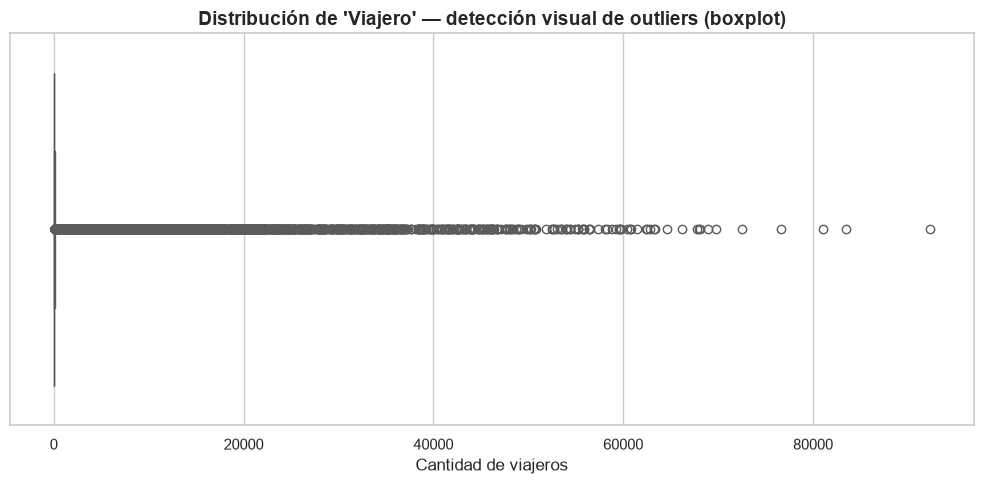

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Viajero"], color="#DD8452")
plt.title("Distribución de 'Viajero' — detección visual de outliers (boxplot)")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()


In [13]:
# Método IQR para cuantificar outliers
Q1 = df["Viajero"].quantile(0.25)
Q3 = df["Viajero"].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df["Viajero"] < lim_inf) | (df["Viajero"] > lim_sup)]
print(f"Límite inferior: {lim_inf:.2f} | Límite superior: {lim_sup:.2f}")
print(f"Cantidad de registros atípicos: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}% del total)")

outliers.sort_values("Viajero", ascending=False).head(10)


Límite inferior: -53.34 | Límite superior: 94.23
Cantidad de registros atípicos: 26,390 (16.39% del total)


,Año,Mes_cod,Mes,Vía,Frontera,País,Región,Región_dos,Regiones_OMT,MCEO,Agrupación_Residencia,Tipo_Viajero,Viajero,Fecha
98206,2017,8,Ago,Terrestre,20 Melchor de Mencos,Belice,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Belice,Viajero,92336.035067,2017-08-01
124846,2019,12,Dic,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,83511.000000,2019-12-01
113144,2018,12,Dic,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,81030.061080,2018-12-01
143464,2022,12,Dic,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,76588.000000,2022-12-01
101056,2017,12,Dic,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,72545.000000,2017-12-01
158357,2025,12,Dic,Terrestre,07 Valle Nuevo,El Salvador,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,El Salvador,Turista,69805.998425,2025-12-01
123854,2019,11,Nov,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,68877.000000,2019-11-01
153238,2024,12,Dic,Terrestre,07 Valle Nuevo,El Salvador,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,El Salvador,Turista,68085.768243,2024-12-01
158279,2025,12,Dic,Aérea,01 La Aurora,Estados Unidos de América,AMÉRICA DEL NORTE,América Del Norte,AMÉRICA DEL NORTE,02 NORTEAMÉRICA,Estados Unidos de América,Turista,67952.000000,2025-12-01
77012,2015,12,Dic,Aérea,01 La Aurora,Guatemala,AMÉRICA DEL CENTRO,América Del Centro,AMÉRICA CENTRAL,01 CENTROAMÉRICA,Guatemala,Turista,67786.000000,2015-12-01


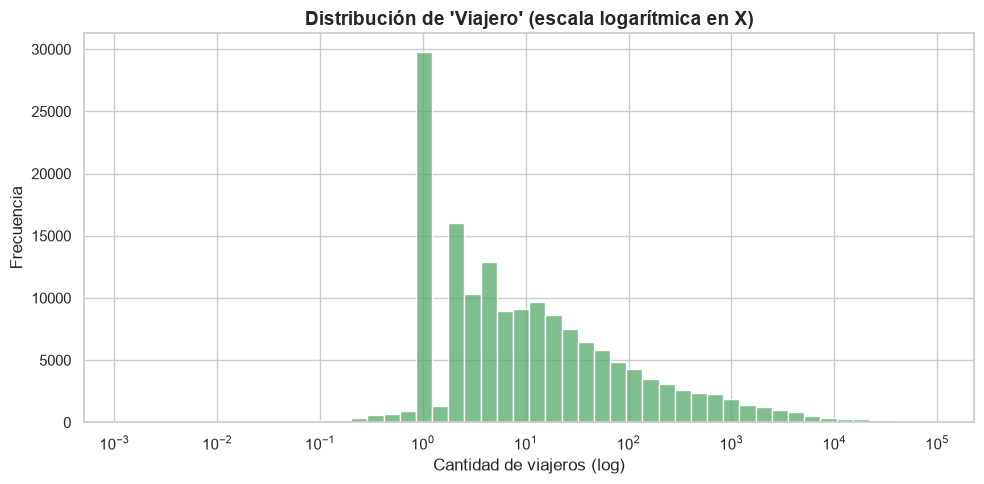

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Viajero"][df["Viajero"] > 0], bins=50, log_scale=(True, False), color="#55A868")
plt.title("Distribución de 'Viajero' (escala logarítmica en X)")
plt.xlabel("Cantidad de viajeros (log)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


Como podemos ver la distrubucion de viajeros en general llega a ser asimetrica y sesgada a la izquierda. esto denota que mayoritariamente se viaja en grupos relativamente pequeños (siendo principalmente una persona).

## 4. Comportamiento temporal del número de viajeros

### 4.1 Serie de tiempo general

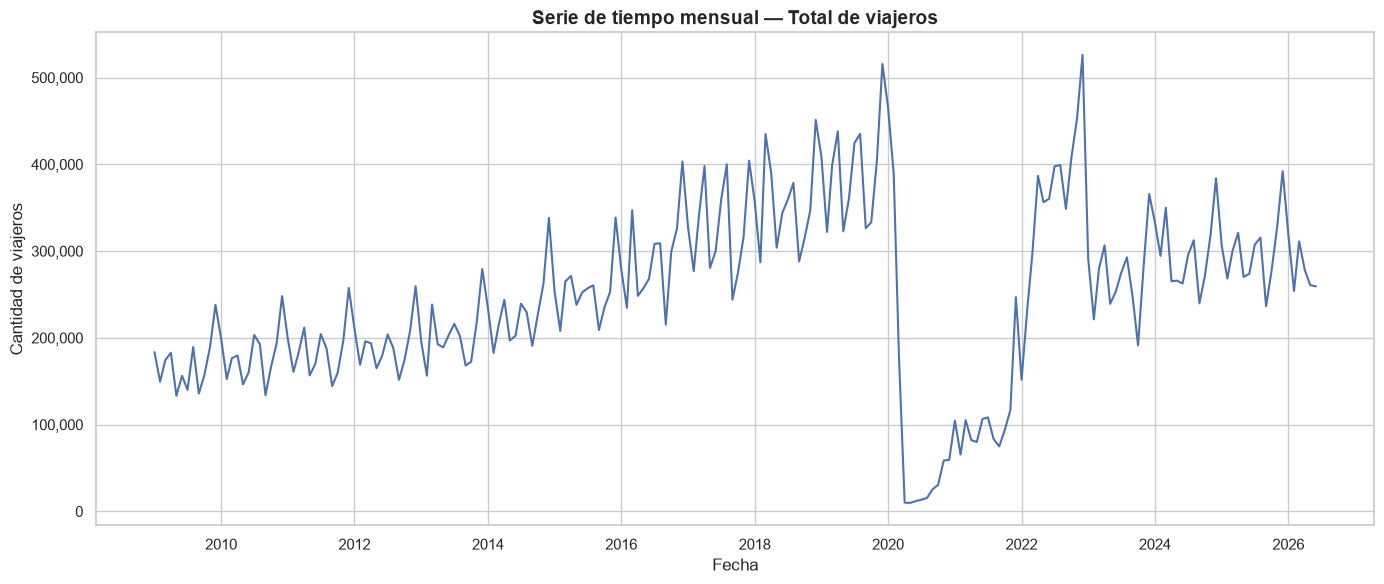

In [15]:
serie_mensual = df.groupby("Fecha", as_index=False)["Viajero"].sum().sort_values("Fecha")

plt.figure(figsize=(14, 6))
plt.plot(serie_mensual["Fecha"], serie_mensual["Viajero"], color="#4C72B0", linewidth=1.5)
plt.title("Serie de tiempo mensual — Total de viajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


Como podemos ver si parecia a tener tendencia, exceptuando por la epoca de pandemia.

### 4.2 Serie anual

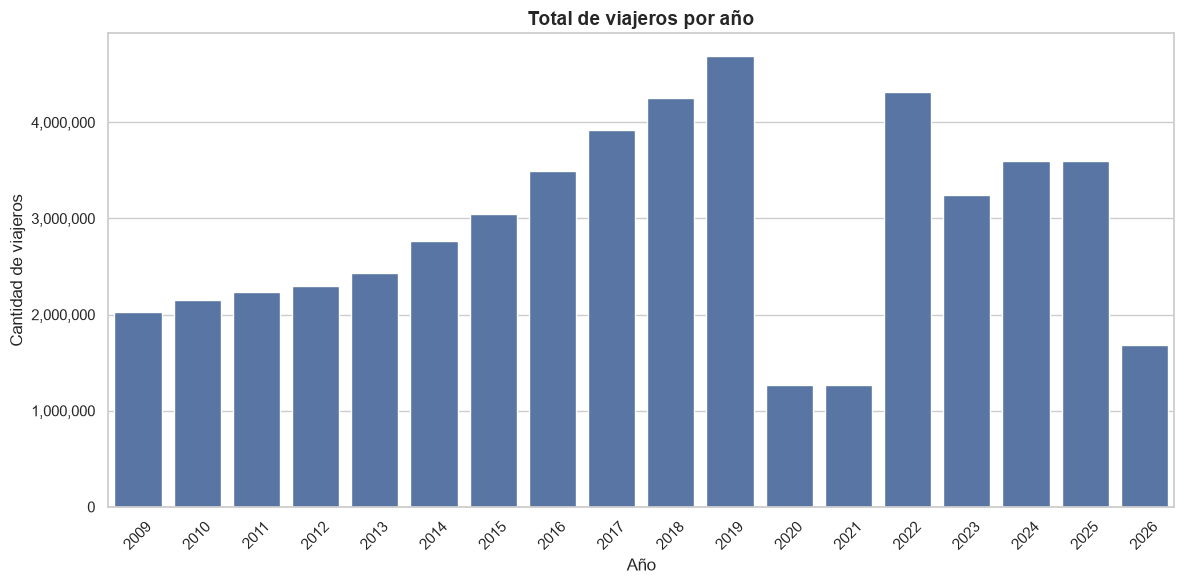

In [16]:
serie_anual = df.groupby("Año", as_index=False)["Viajero"].sum()

plt.figure(figsize=(12, 6))
sns.barplot(data=serie_anual, x="Año", y="Viajero", color="#4C72B0")
plt.xticks(rotation=45)
plt.title("Total de viajeros por año")
plt.ylabel("Cantidad de viajeros")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


In [17]:
# Variación porcentual año contra año (YoY)
serie_anual["YoY_%"] = serie_anual["Viajero"].pct_change() * 100
serie_anual


,Año,Viajero,YoY_%
0,2009,2.028776e+06,NaN
1,2010,2.152899e+06,6.118130
2,2011,2.231456e+06,3.648906
3,2012,2.299816e+06,3.063447
4,2013,2.432169e+06,5.754957
5,2014,2.762602e+06,13.585939
6,2015,3.041643e+06,10.100645
7,2016,3.496217e+06,14.945025
8,2017,3.921460e+06,12.162960
9,2018,4.256349e+06,8.539889


### 4.3 Estacionalidad mensual

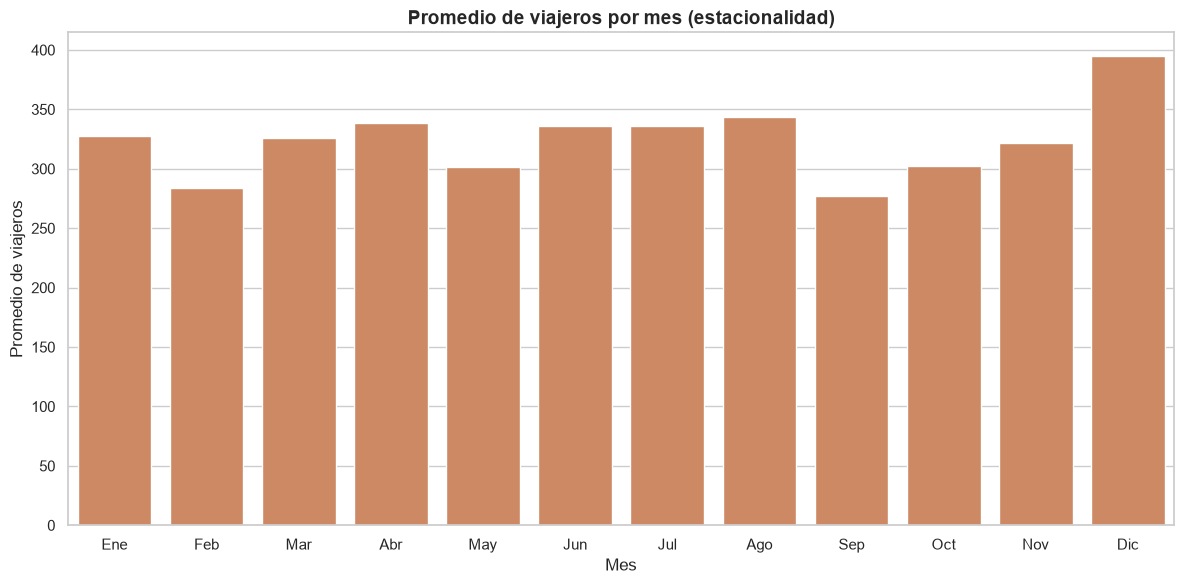

In [18]:
orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

serie_mensual_prom = df.groupby("Mes", as_index=False)["Viajero"].mean()
serie_mensual_prom["Mes"] = pd.Categorical(serie_mensual_prom["Mes"], categories=orden_meses, ordered=True)
serie_mensual_prom = serie_mensual_prom.sort_values("Mes")

plt.figure(figsize=(12, 6))
sns.barplot(data=serie_mensual_prom, x="Mes", y="Viajero", color="#DD8452")
plt.title("Promedio de viajeros por mes (estacionalidad)")
plt.ylabel("Promedio de viajeros")
plt.tight_layout()
plt.show()


### 4.4 Serie temporal por tipo de viajero

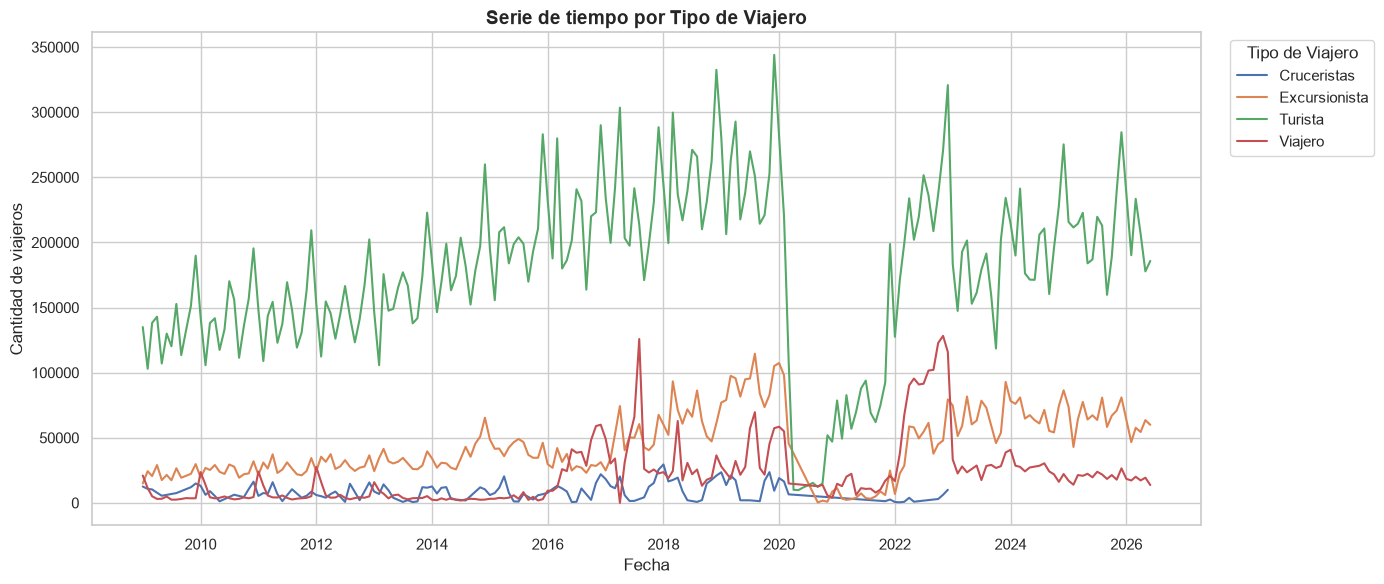

In [19]:
serie_tipo = df.groupby(["Fecha", "Tipo_Viajero"], as_index=False)["Viajero"].sum()

plt.figure(figsize=(14, 6))
sns.lineplot(data=serie_tipo, x="Fecha", y="Viajero", hue="Tipo_Viajero")
plt.title("Serie de tiempo por Tipo de Viajero")
plt.ylabel("Cantidad de viajeros")
plt.legend(title="Tipo de Viajero", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 4.5 Serie temporal por vía de ingreso

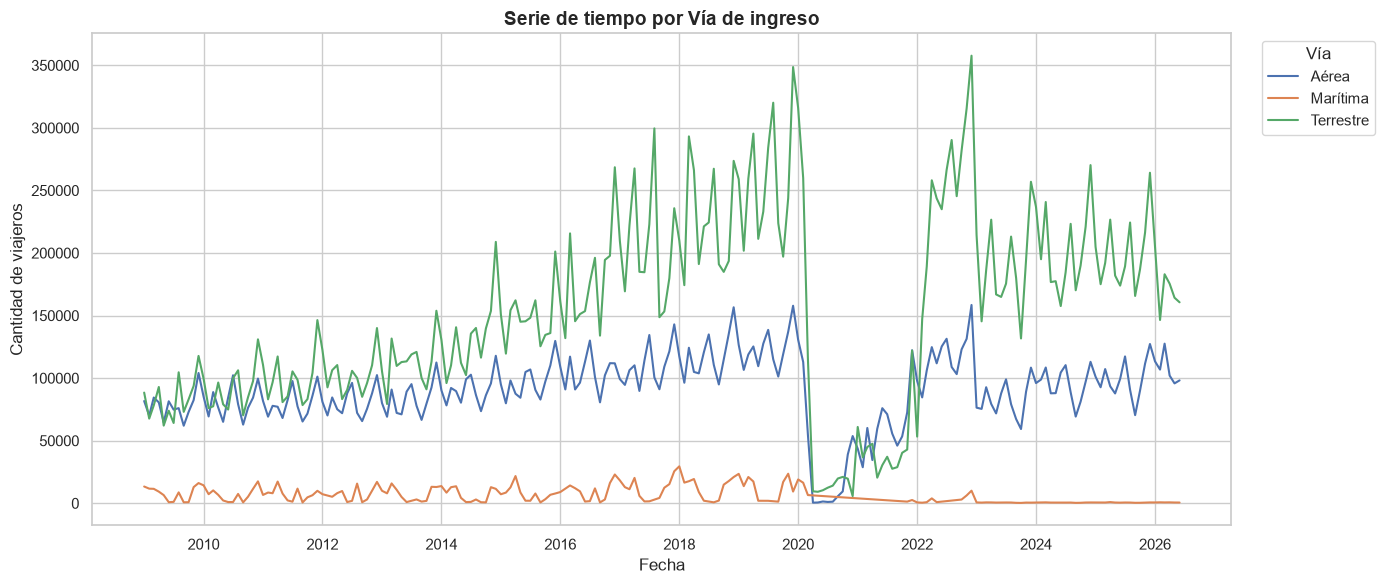

In [20]:
serie_via = df.groupby(["Fecha", "Vía"], as_index=False)["Viajero"].sum()

plt.figure(figsize=(14, 6))
sns.lineplot(data=serie_via, x="Fecha", y="Viajero", hue="Vía")
plt.title("Serie de tiempo por Vía de ingreso")
plt.ylabel("Cantidad de viajeros")
plt.legend(title="Vía", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Como podemos ver si llegan a tener una tendencia bastante similar entre ellos, teniendo los picos en tiempos similares entre ellos, tomando siempre en cuenta la caida del covid.

## 5. Información general

### 5.1 Países con mayor cantidad de viajeros

> Se segmenta en antes y después de 2023 por el cambio de definición de la variable País.

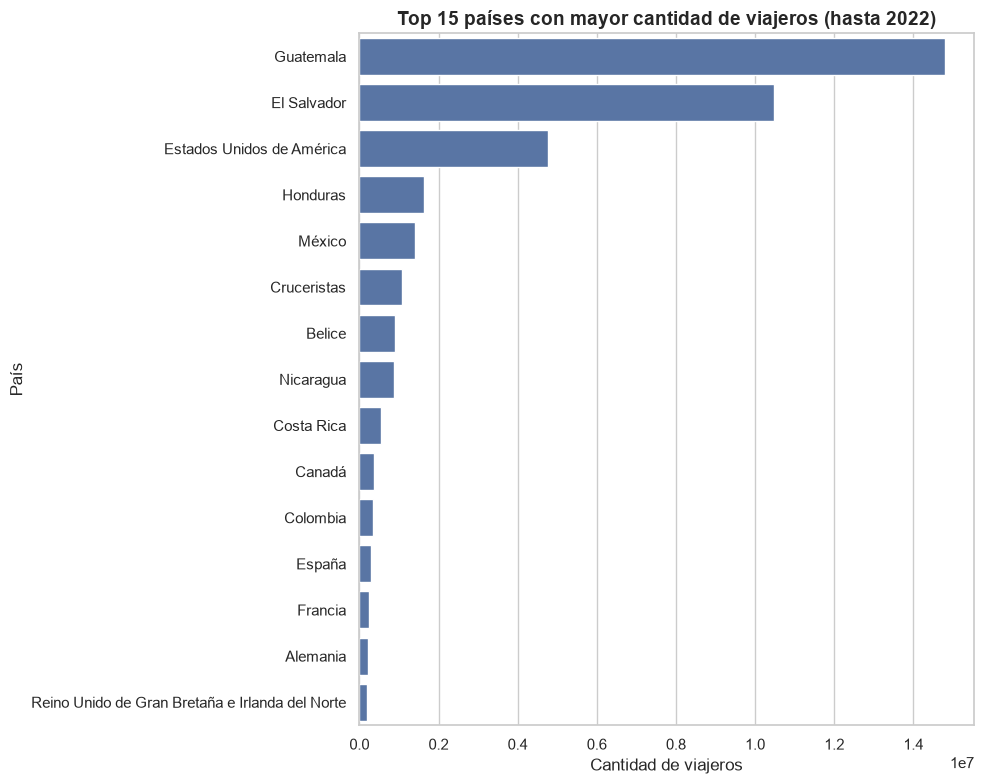

In [21]:
df_pre2023 = df[df["Año"] < 2023]
df_post2023 = df[df["Año"] >= 2023]

top_paises_pre = (df_pre2023.groupby("País")["Viajero"].sum()
                   .sort_values(ascending=False).head(15))

plt.figure(figsize=(10, 8))
sns.barplot(x=top_paises_pre.values, y=top_paises_pre.index, color="#4C72B0")
plt.title("Top 15 países con mayor cantidad de viajeros (hasta 2022)")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()


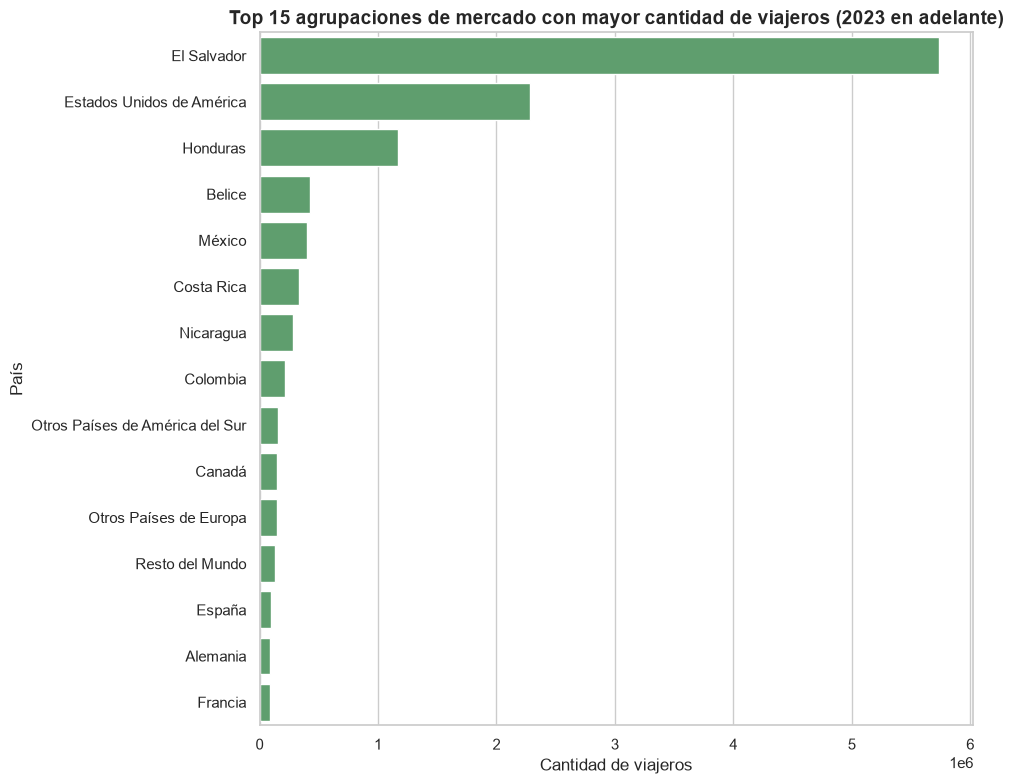

In [22]:
if not df_post2023.empty:
    top_paises_post = (df_post2023.groupby("País")["Viajero"].sum()
                        .sort_values(ascending=False).head(15))

    plt.figure(figsize=(10, 8))
    sns.barplot(x=top_paises_post.values, y=top_paises_post.index, color="#55A868")
    plt.title("Top 15 agrupaciones de mercado con mayor cantidad de viajeros (2023 en adelante)")
    plt.xlabel("Cantidad de viajeros")
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para 2023 en adelante en este dataset.")


Interpretación: _(completar tras ejecutar)_ Identificar si el país líder se mantiene
constante en el tiempo o si ha cambiado, y qué tan concentrada está la llegada de viajeros en
pocos países (ej. ¿el top 5 representa más del 50% del total?).

### 5.2 Regiones con mayor cantidad de viajeros

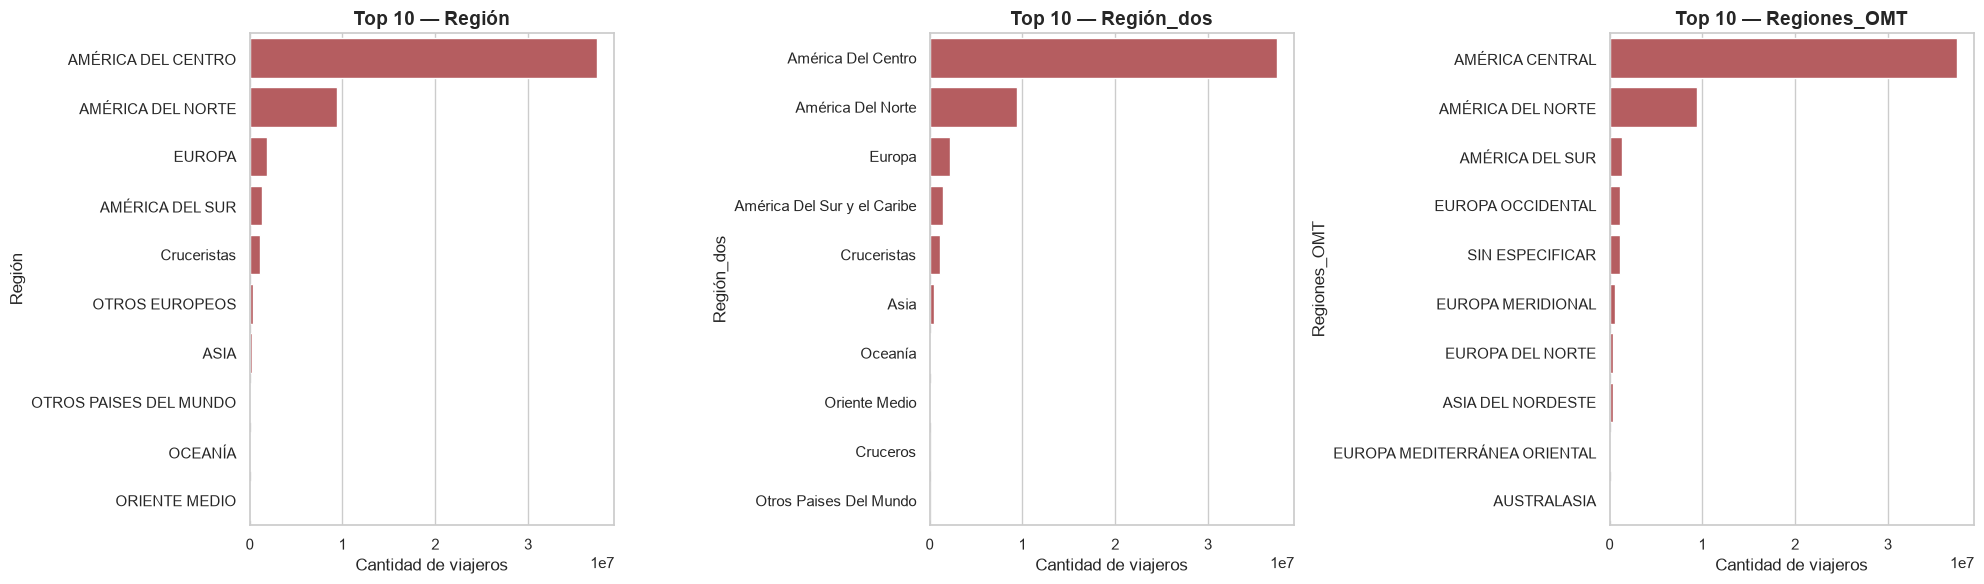

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, col in zip(axes, ["Región", "Región_dos", "Regiones_OMT"]):
    top_region = df.groupby(col)["Viajero"].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=top_region.values, y=top_region.index, ax=ax, color="#C44E52")
    ax.set_title(f"Top 10 — {col}")
    ax.set_xlabel("Cantidad de viajeros")

plt.tight_layout()
plt.show()


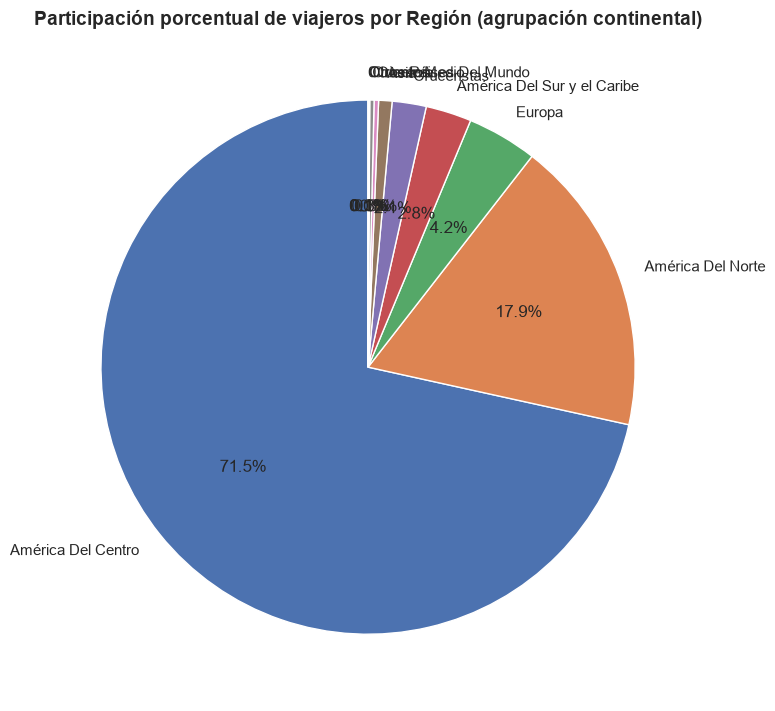

In [24]:
# Participación porcentual por Región dos (nivel más agregado / continental)
participacion_region = (df.groupby("Región_dos")["Viajero"].sum()
                         .sort_values(ascending=False))
participacion_region_pct = (participacion_region / participacion_region.sum() * 100).round(2)

plt.figure(figsize=(8, 8))
plt.pie(participacion_region_pct, labels=participacion_region_pct.index,
        autopct="%1.1f%%", startangle=90)
plt.title("Participación porcentual de viajeros por Región (agrupación continental)")
plt.tight_layout()
plt.show()


### 5.3 Vías de ingreso y fronteras más utilizadas

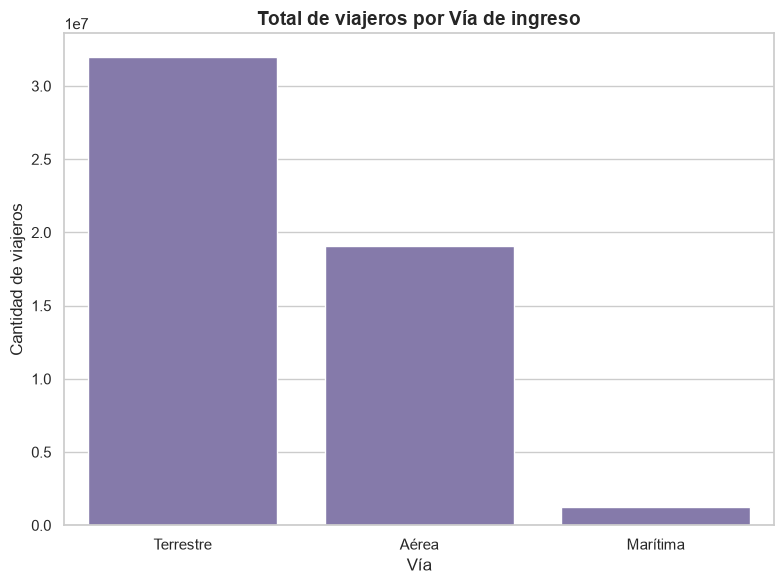

In [25]:
plt.figure(figsize=(8, 6))
via_totales = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
sns.barplot(x=via_totales.index, y=via_totales.values, color="#8172B2")
plt.title("Total de viajeros por Vía de ingreso")
plt.ylabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()


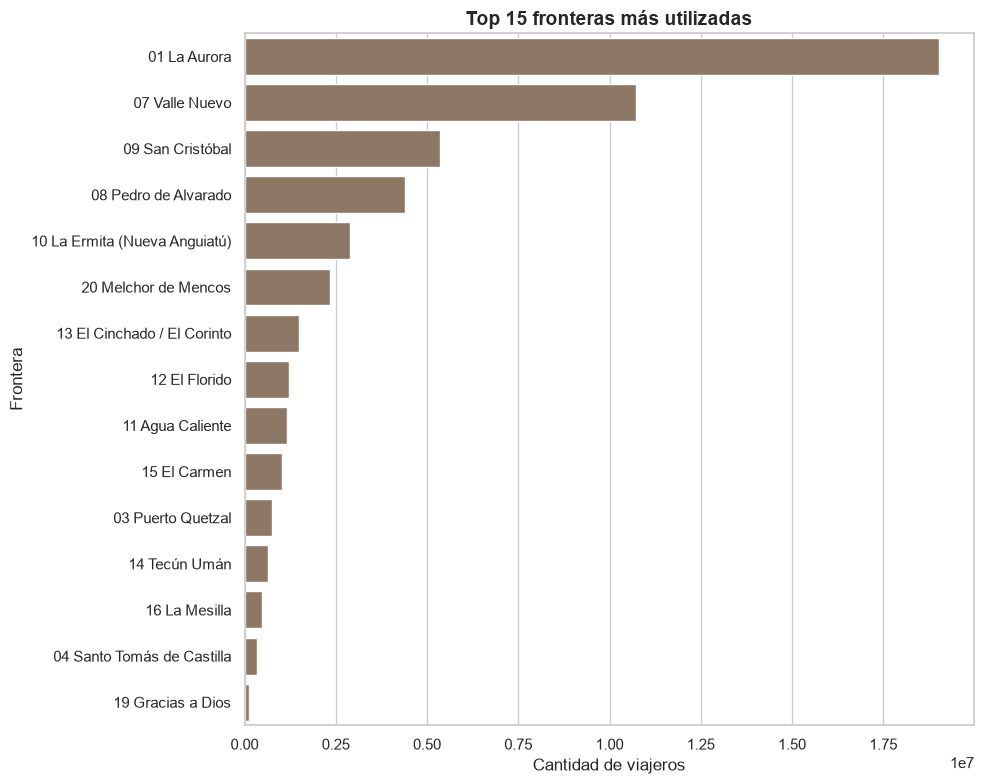

In [26]:
top_fronteras = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_fronteras.values, y=top_fronteras.index, color="#937860")
plt.title("Top 15 fronteras más utilizadas")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()


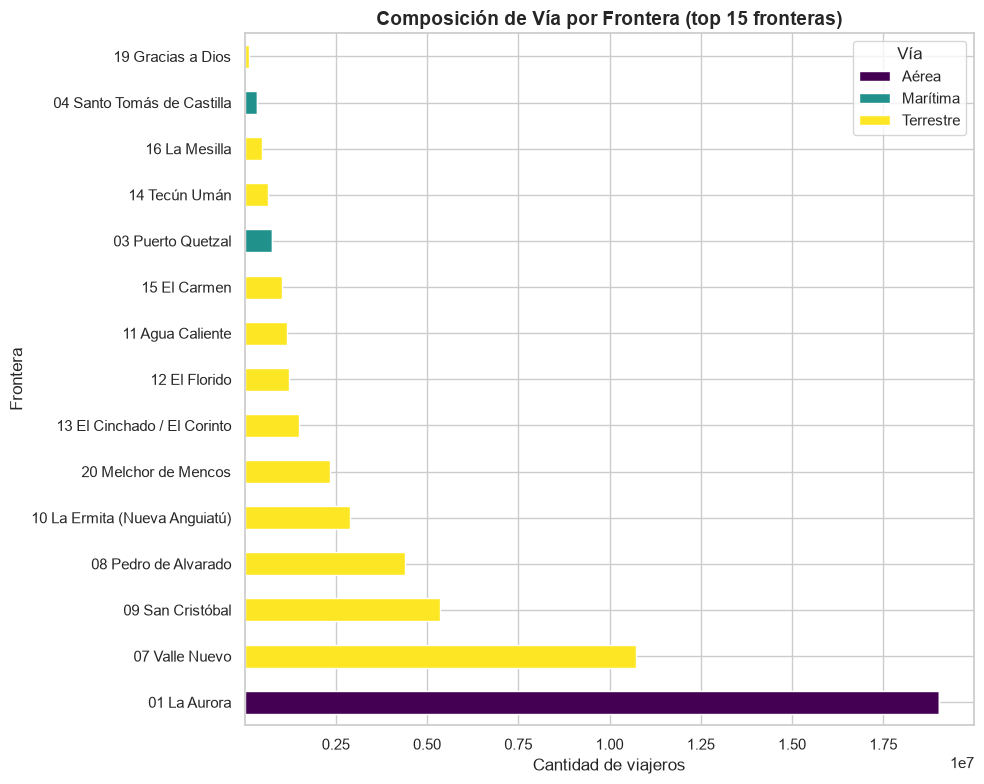

In [27]:
# Cruce Vía x Frontera (top fronteras) para ver composición
top_fronteras_list = top_fronteras.index.tolist()
cruce_via_frontera = (df[df["Frontera"].isin(top_fronteras_list)]
                       .pivot_table(index="Frontera", columns="Vía", values="Viajero", aggfunc="sum", fill_value=0))
cruce_via_frontera = cruce_via_frontera.loc[top_fronteras_list]

cruce_via_frontera.plot(kind="barh", stacked=True, figsize=(10, 8), colormap="viridis")
plt.title("Composición de Vía por Frontera (top 15 fronteras)")
plt.xlabel("Cantidad de viajeros")
plt.tight_layout()
plt.show()


## 6. Estadísticas descriptivas generales

In [28]:
df["Viajero"].describe()


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

In [29]:
# Estadísticas descriptivas por Tipo de Viajero
df.groupby("Tipo_Viajero")["Viajero"].describe()


,count,mean,std,min,25%,50%,75%,max
Tipo_Viajero,,,,,,,,
Cruceristas,204.0,5413.735294,4225.763359,85.0,2094.0,4454.906604,7173.500000,21680.933573
Excursionista,19730.0,459.664690,1833.670984,0.0,2.0,10.000000,80.255455,38463.026064
Turista,117912.0,319.244255,2611.324160,0.0,2.0,6.000000,33.000000,83511.000000
Viajero,23190.0,192.825451,1281.234973,0.0,2.0,8.181818,44.000000,92336.035067


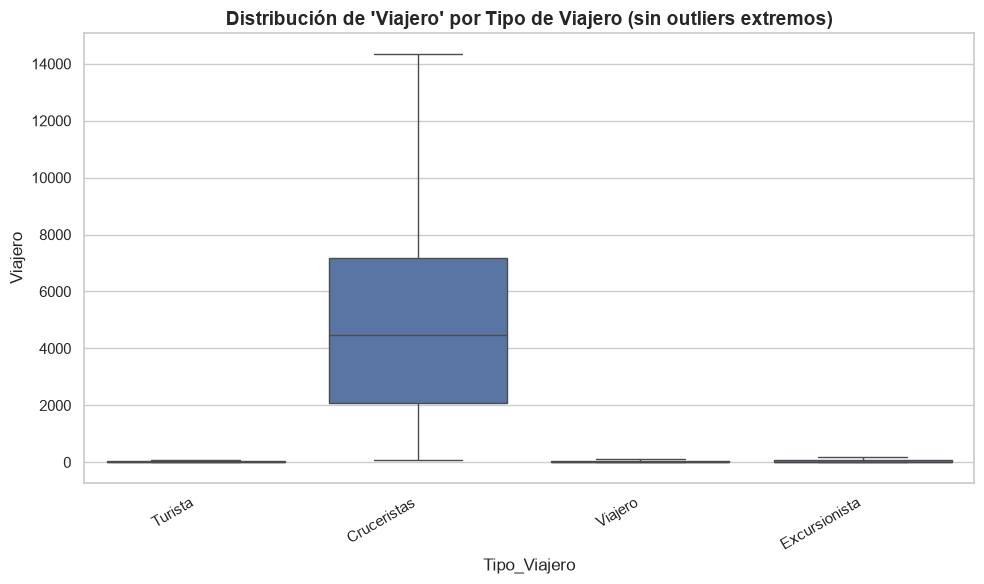

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Tipo_Viajero", y="Viajero", showfliers=False)
plt.title("Distribución de 'Viajero' por Tipo de Viajero (sin outliers extremos)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


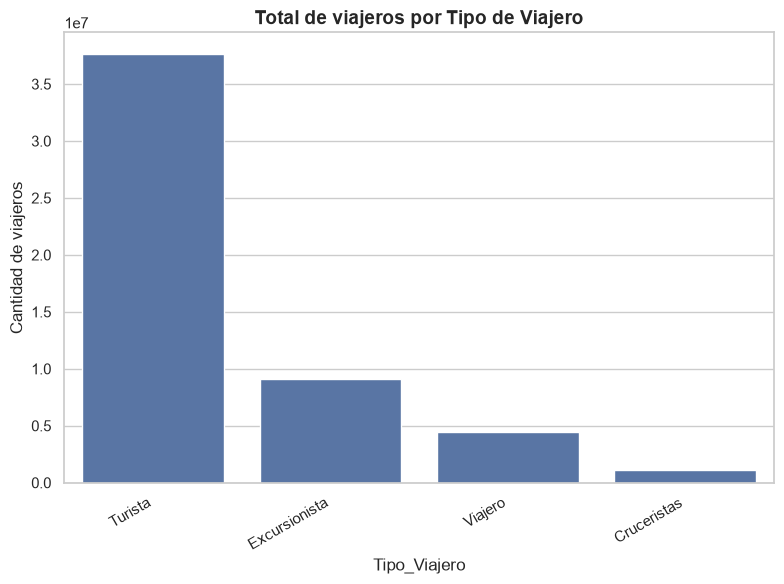

In [31]:
top_tipo = df.groupby("Tipo_Viajero")["Viajero"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_tipo.index, y=top_tipo.values, color="#4C72B0")
plt.title("Total de viajeros por Tipo de Viajero")
plt.ylabel("Cantidad de viajeros")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 7. Divida el conjunto de datos en entrenamiento y prueba, aproximadamente 70% entrenamiento, 30% para prueba.

Entrenamiento: 2009-01-01 a 2021-03-01 (147 meses, 70.0%)
Prueba: 2021-04-01 a 2026-06-01 (63 meses, 30.0%)


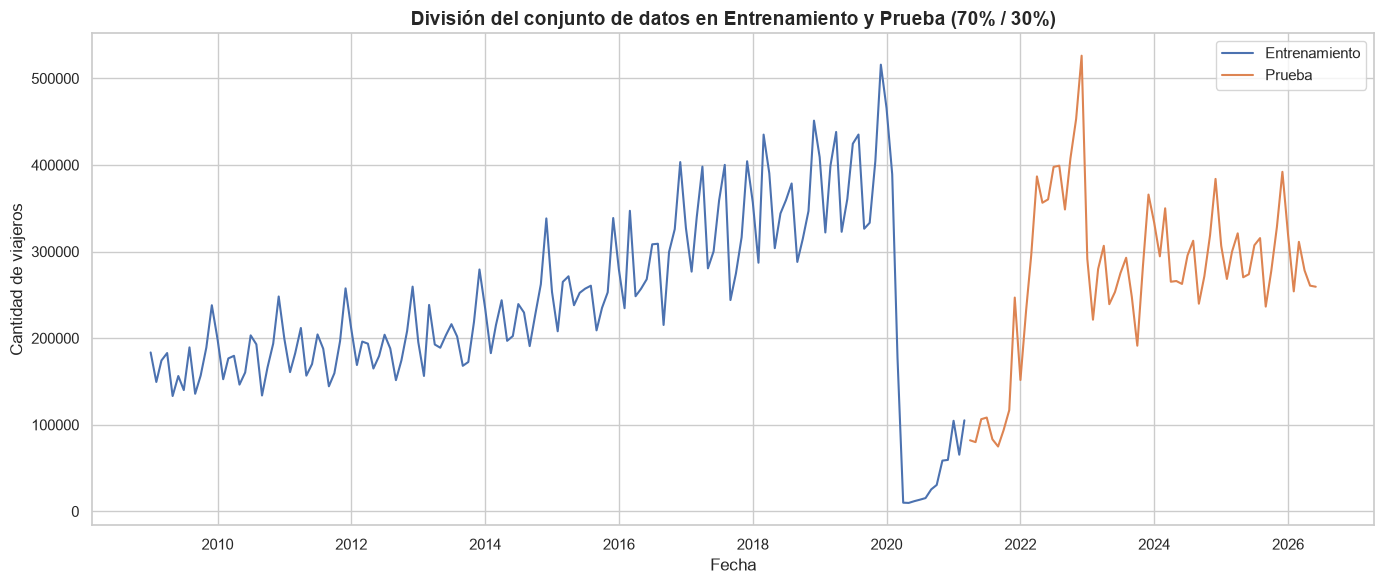

In [32]:
serie = df.groupby("Fecha", as_index=False)["Viajero"].sum().sort_values("Fecha")

train, test = serie.iloc[:int(0.7 * len(serie))], serie.iloc[int(0.7 * len(serie)):]

# Subconjuntos a nivel de fila (necesarios para agregar por categoría en el punto 8)
df_train = df[df["Fecha"] <= train["Fecha"].max()].copy()
df_test = df[df["Fecha"] > train["Fecha"].max()].copy()

print(f"Entrenamiento: {train['Fecha'].min().date()} a {train['Fecha'].max().date()} "
      f"({len(train)} meses, {len(train)/len(serie)*100:.1f}%)")
print(f"Prueba: {test['Fecha'].min().date()} a {test['Fecha'].max().date()} "
      f"({len(test)} meses, {len(test)/len(serie)*100:.1f}%)")

plt.figure(figsize=(14, 6))
plt.plot(train["Fecha"], train["Viajero"], label="Entrenamiento", color="#4C72B0", linewidth=1.5)
plt.plot(test["Fecha"], test["Viajero"], label="Prueba", color="#DD8452", linewidth=1.5)
plt.title("División del conjunto de datos en Entrenamiento y Prueba (70% / 30%)")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.tight_layout()
plt.show()

## 8. A partir del conjunto de datos de entrenamiento construya series de tiempo mensuales, agregando el número de viajeros según la categoría correspondiente. Si considera que necesita limpieza hágala.

a. Serie obligatoria: Total mensual de viajeros internacionales.

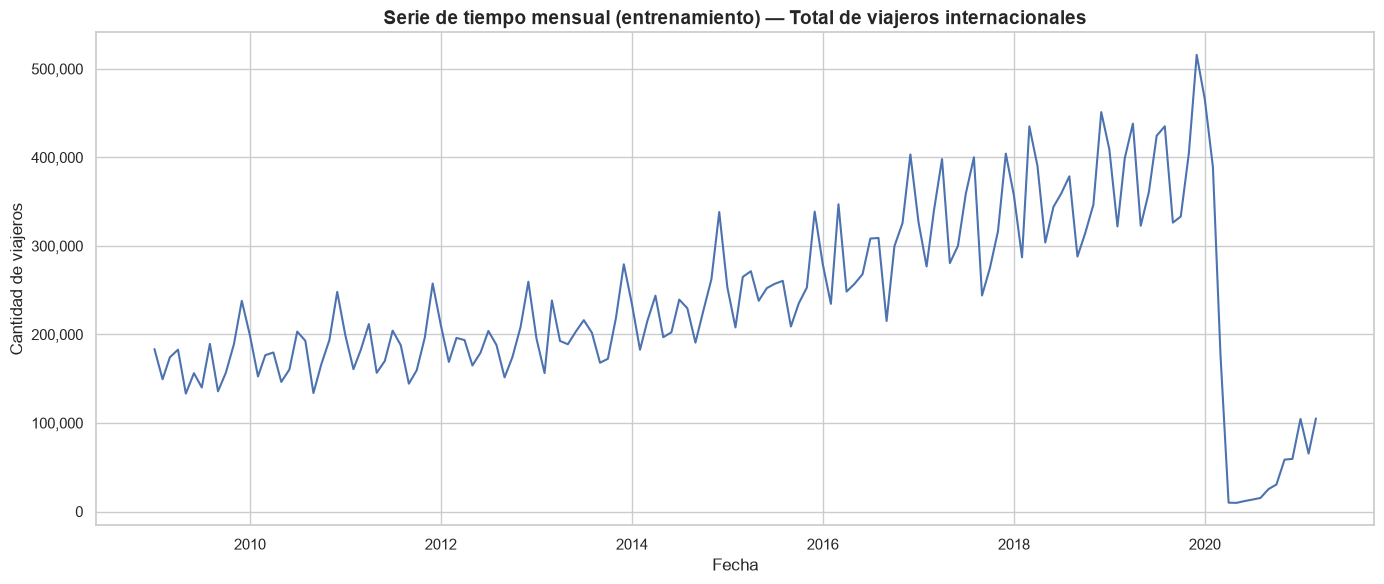

In [33]:
total_mensual_internacionales = train

plt.figure(figsize=(14, 6))
plt.plot(total_mensual_internacionales["Fecha"], total_mensual_internacionales["Viajero"], color="#4C72B0", linewidth=1.5)
plt.title("Serie de tiempo mensual (entrenamiento) — Total de viajeros internacionales")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


b.1. Países de residencia
Construya una serie mensual para cada uno de los tres países con
mayor número acumulado de viajeros durante todo el período de
estudio (Top 3). En total deberá obtener tres series.

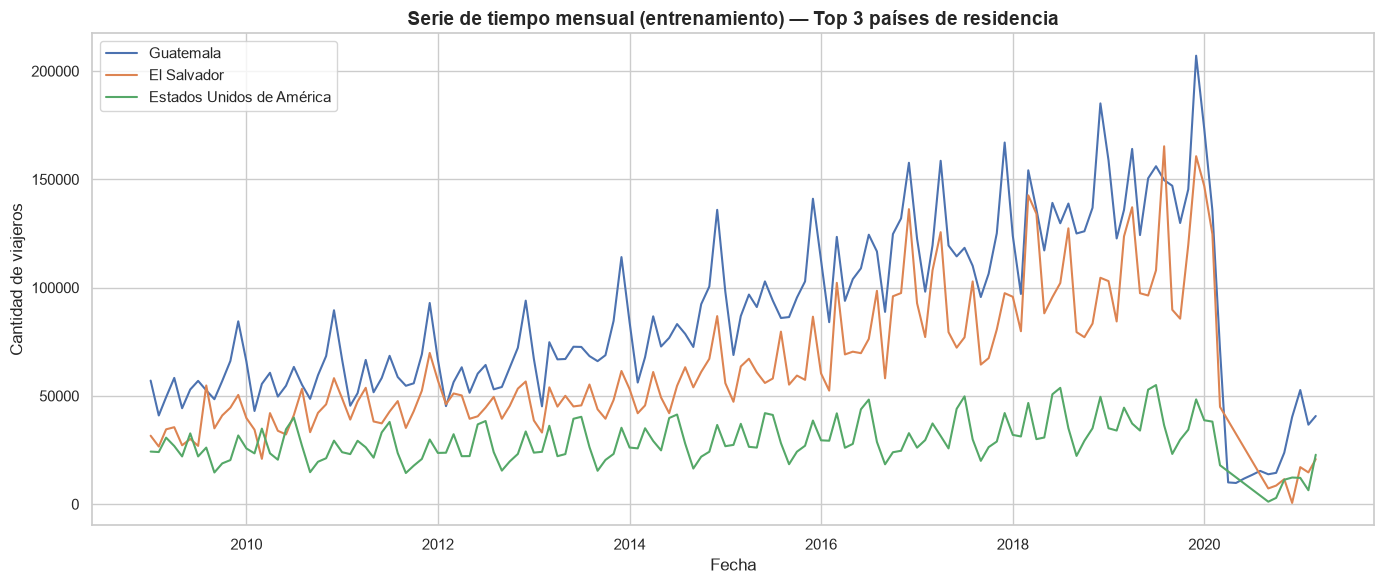

In [34]:
paises_top3 = df_train.groupby("País")["Viajero"].sum().sort_values(ascending=False).head(3).index.tolist()

plt.figure(figsize=(14, 6))
for pais in paises_top3:
    serie_pais = df_train[df_train["País"] == pais].groupby("Fecha", as_index=False)["Viajero"].sum().sort_values("Fecha")
    plt.plot(serie_pais["Fecha"], serie_pais["Viajero"], label=pais, linewidth=1.5)
plt.title("Serie de tiempo mensual (entrenamiento) — Top 3 países de residencia")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.tight_layout()
plt.show()

b.2. Tipo de viajero
Construya una serie mensual para cada tipo de viajero presente en el conjunto de datos (por ejemplo, Turista, Excursionista, etc.). En total deberá obtener una serie por cada categoría existente.

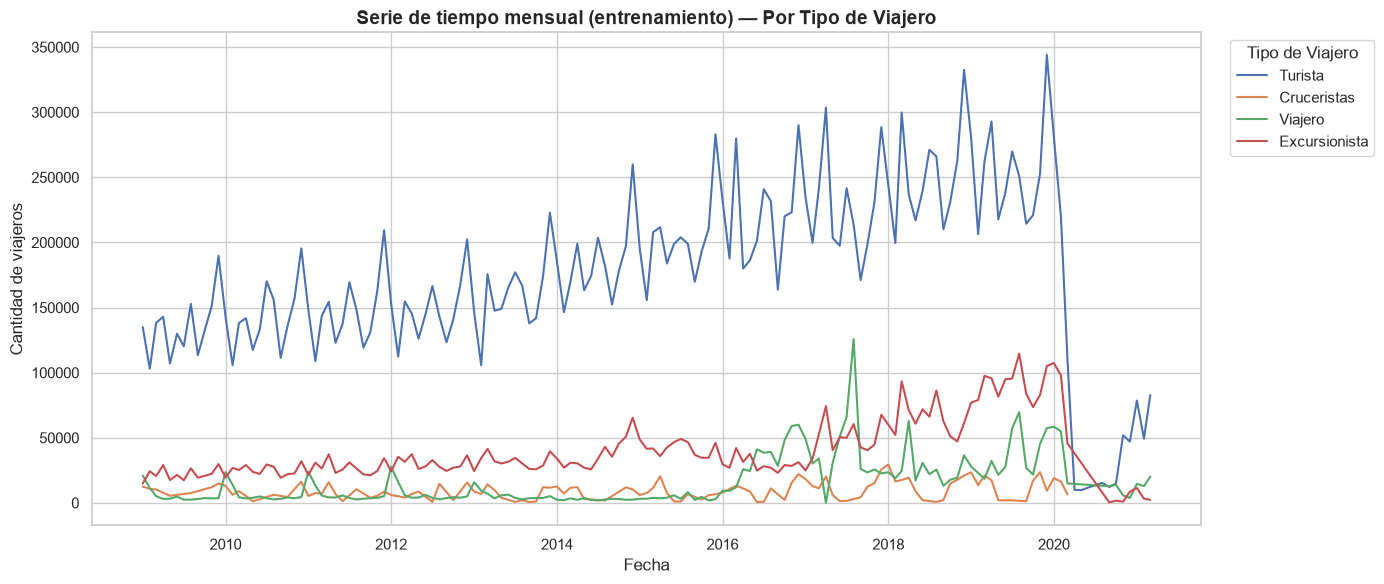

In [35]:
tipo_viajeros = df_train["Tipo_Viajero"].unique().tolist()

plt.figure(figsize=(14, 6))
for tipo in tipo_viajeros:
    serie_tipo = df_train[df_train["Tipo_Viajero"] == tipo].groupby("Fecha", as_index=False)["Viajero"].sum().sort_values("Fecha")
    plt.plot(serie_tipo["Fecha"], serie_tipo["Viajero"], label=tipo, linewidth=1.5)
plt.title("Serie de tiempo mensual (entrenamiento) — Por Tipo de Viajero")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend(title="Tipo de Viajero", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 9. Analisis de cada serie de tiempo construida en el paso anterior

a. Especifique Inicio, fin, y frecuencia.

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Consolidamos en un diccionario las 8 series construidas en el punto 8,
# usando únicamente el período de entrenamiento (train / df_train).
series_dict = {"Total internacionales": train.set_index("Fecha")["Viajero"]}

rango_fechas = pd.date_range(train["Fecha"].min(), train["Fecha"].max(), freq="MS")

for pais in paises_top3:
    s = (df_train[df_train["País"] == pais]
         .groupby("Fecha")["Viajero"].sum()
         .reindex(rango_fechas, fill_value=0))
    series_dict[f"País: {pais}"] = s

for tipo in tipo_viajeros:
    s = (df_train[df_train["Tipo_Viajero"] == tipo]
         .groupby("Fecha")["Viajero"].sum()
         .reindex(rango_fechas, fill_value=0))
    series_dict[f"Tipo: {tipo}"] = s

resumen_series = pd.DataFrame([
    {
        "Serie": nombre,
        "Inicio": s.index.min().date(),
        "Fin": s.index.max().date(),
        "Frecuencia": pd.infer_freq(s.index),
        "N° observaciones": len(s),
    }
    for nombre, s in series_dict.items()
])
resumen_series

,Serie,Inicio,Fin,Frecuencia,N° observaciones
0,Total internacionales,2009-01-01,2021-03-01,MS,147
1,País: Guatemala,2009-01-01,2021-03-01,MS,147
2,País: El Salvador,2009-01-01,2021-03-01,MS,147
3,País: Estados Unidos de América,2009-01-01,2021-03-01,MS,147
4,Tipo: Turista,2009-01-01,2021-03-01,MS,147
5,Tipo: Cruceristas,2009-01-01,2021-03-01,MS,147
6,Tipo: Viajero,2009-01-01,2021-03-01,MS,147
7,Tipo: Excursionista,2009-01-01,2021-03-01,MS,147


Las 8 series analizadas (total y las derivadas por país y por tipo de viajero) comparten el mismo
índice temporal porque todas provienen del mismo subconjunto de entrenamiento: inician en
enero de 2009, terminan en marzo de 2021 y tienen frecuencia mensual (MS, un valor por
inicio de mes), con 147 observaciones cada una.

b. Haga un gráfico de la serie y explique qué información puede obtener a primera vista.

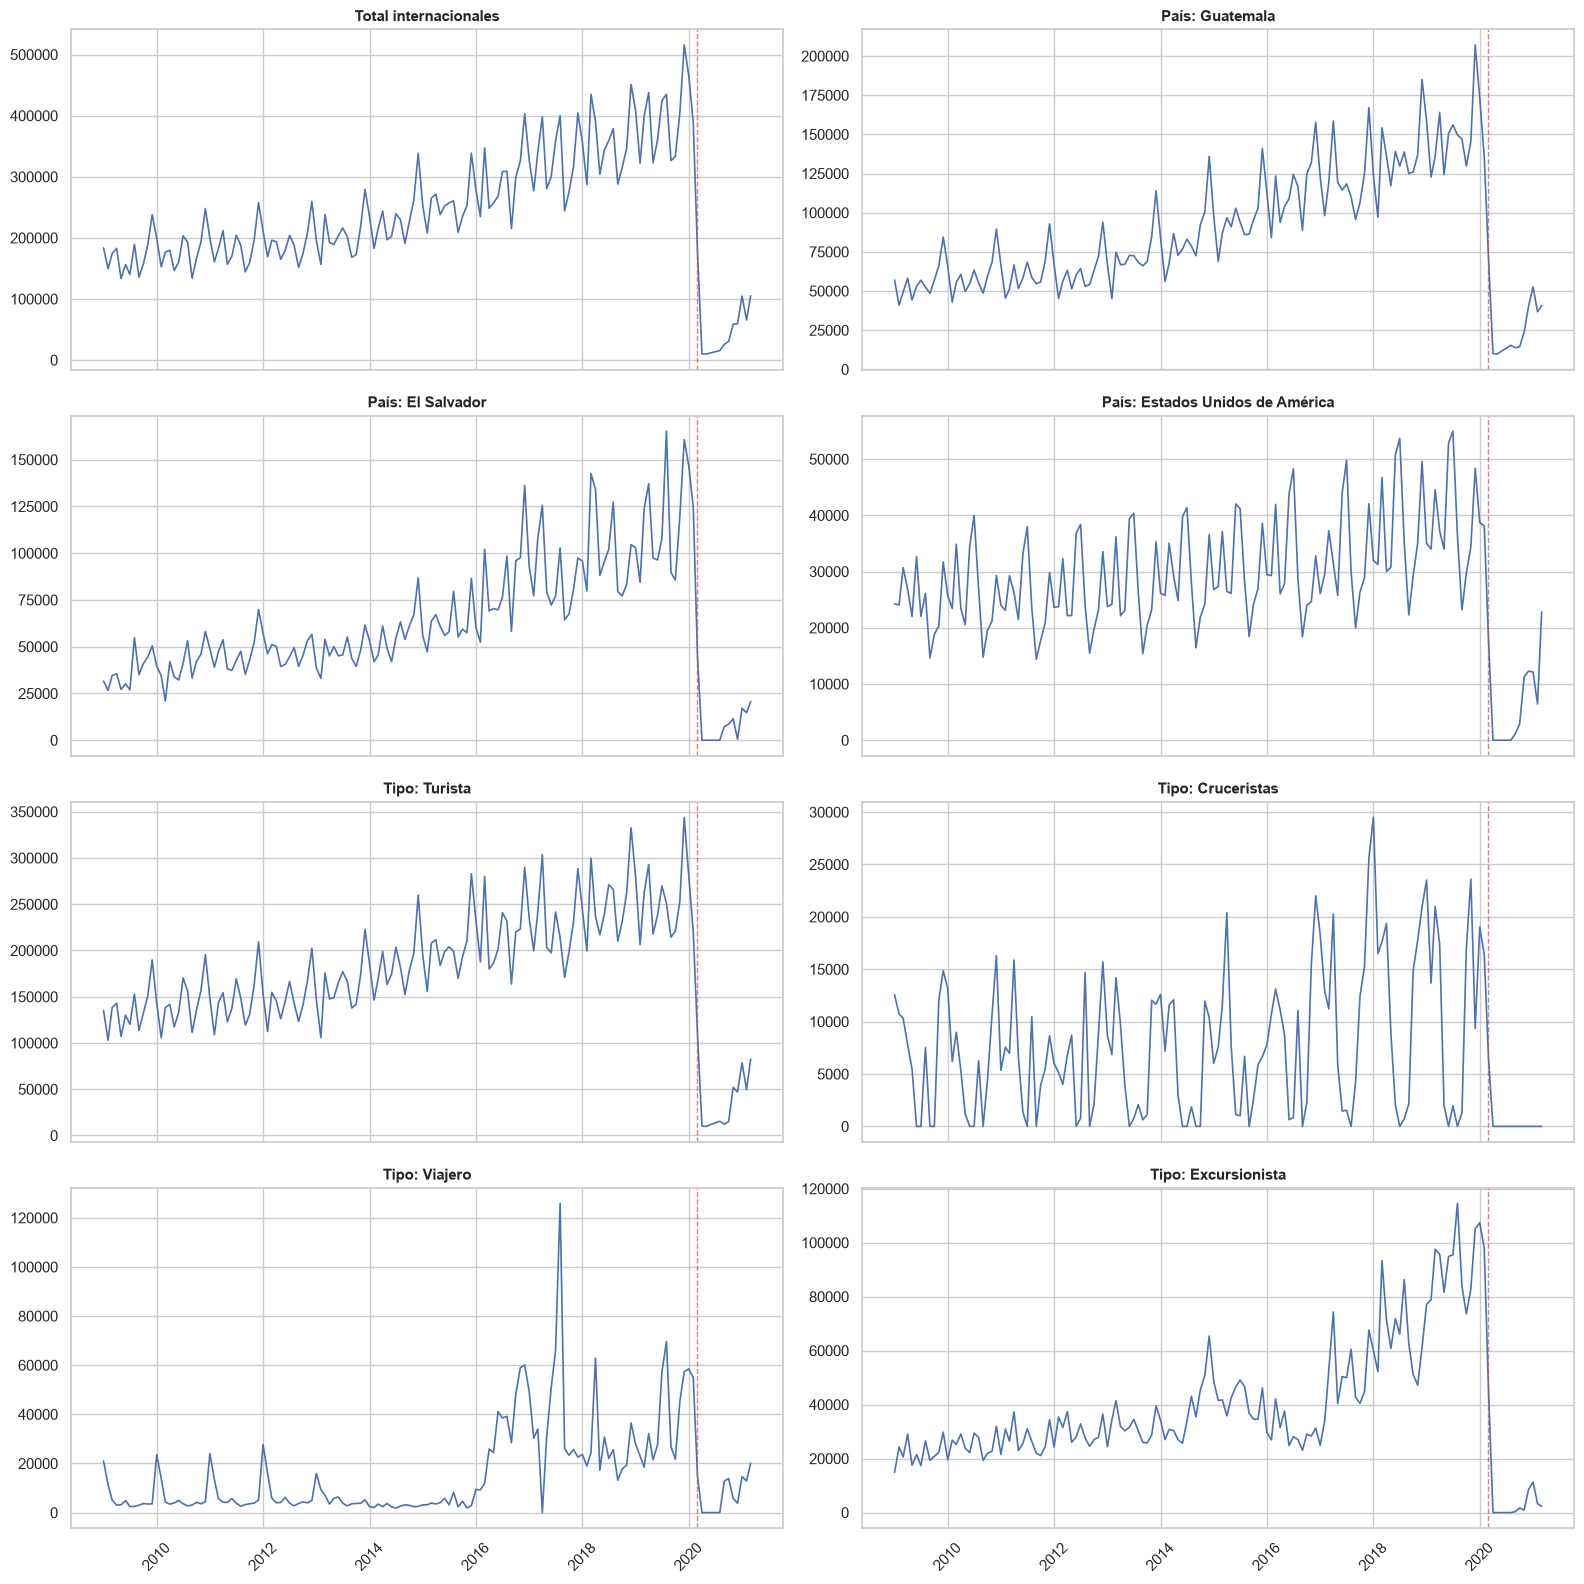

In [37]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=True)

for ax, (nombre, s) in zip(axes.flatten(), series_dict.items()):
    ax.plot(s.index, s.values, linewidth=1.2, color="#4C72B0")
    ax.set_title(nombre, fontsize=11)
    ax.tick_params(axis="x", rotation=45)
    ax.axvline(pd.Timestamp("2020-03-01"), color="#C44E52", linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

A primera vista, todas las series comparten dos rasgos dominantes:

- Tendencia creciente 2009–2019: el número de viajeros crece de forma sostenida en todas las
  categorías, por ejemplo, el total pasa de un promedio mensual de ~194 mil en la primera mitad del
  entrenamiento a ~280 mil en la segunda mitad, con estacionalidad anual visible (diciembre es
  consistentemente el mes de mayor movimiento, seguido de enero/marzo; septiembre es el más bajo).
- Quiebre por COVID-19: en marzo de 2020 todas las series colapsan de forma abrupta y permanecen deprimidas
  durante el resto de 2020, con una recuperación lenta y parcial hacia marzo de 2021.

Las series por tipo de viajero (Viajero, Excursionista, Cruceristas) son visiblemente más
erráticas/ruidosas que Turista, y las series por país difieren en la intensidad de la caída: EE. UU.
(mayormente aéreo) se recupera más rápido que Guatemala y El Salvador (mayormente terrestre), que
dependen de flujos fronterizos más sensibles a restricciones de movilidad.

c. Descomponga la serie. Teniendo en cuenta el diagrama de la serie y sus componentes discuta si es posible hablar de estacionariedad en media y en varianza.

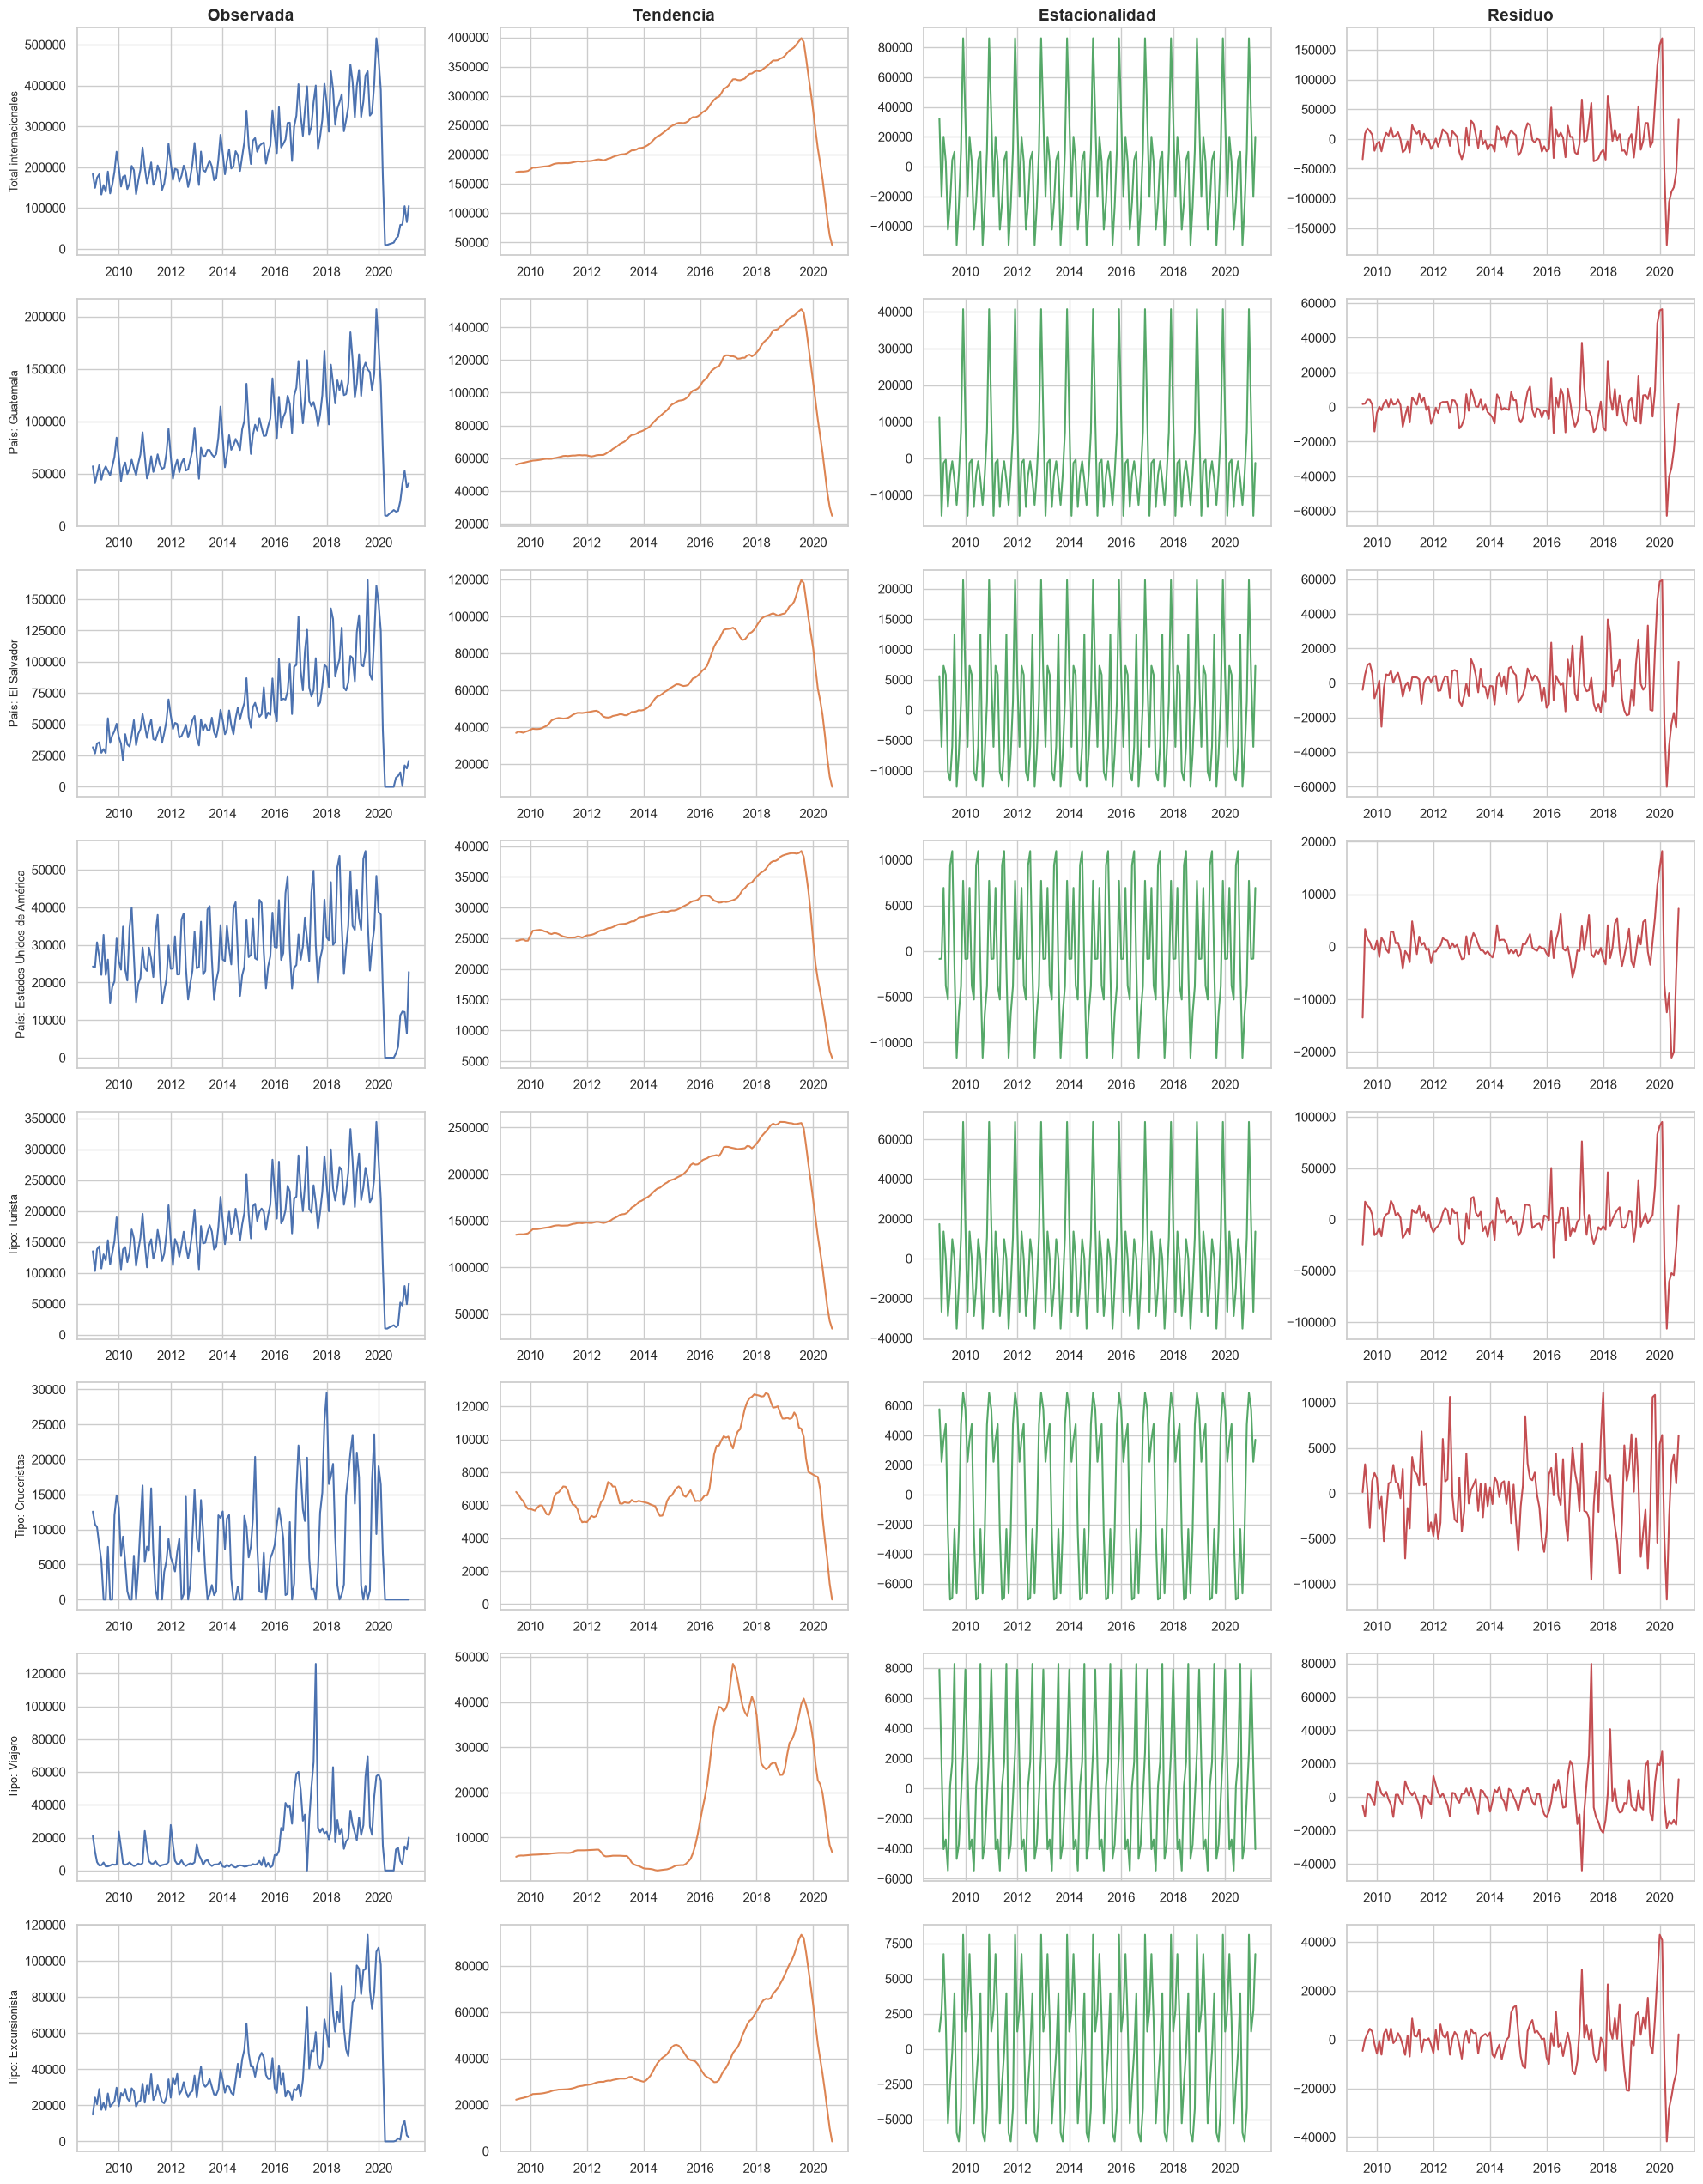

In [38]:
fig, axes = plt.subplots(len(series_dict), 4, figsize=(20, 3.2 * len(series_dict)))

for i, (nombre, s) in enumerate(series_dict.items()):
    dec = seasonal_decompose(s, model="additive", period=12)
    axes[i, 0].plot(dec.observed, color="#4C72B0")
    axes[i, 1].plot(dec.trend, color="#DD8452")
    axes[i, 2].plot(dec.seasonal, color="#55A868")
    axes[i, 3].plot(dec.resid, color="#C44E52")
    axes[i, 0].set_ylabel(nombre, fontsize=9)
    if i == 0:
        for ax, titulo in zip(axes[i], ["Observada", "Tendencia", "Estacionalidad", "Residuo"]):
            ax.set_title(titulo)

plt.tight_layout()
plt.show()

In [39]:
diagnostico_estacionariedad = pd.DataFrame([
    {
        "Serie": nombre,
        "Media 1a mitad": s.iloc[:len(s)//2].mean(),
        "Media 2a mitad": s.iloc[len(s)//2:].mean(),
        "Std 1a mitad": s.iloc[:len(s)//2].std(),
        "Std 2a mitad": s.iloc[len(s)//2:].std(),
    }
    for nombre, s in series_dict.items()
])
diagnostico_estacionariedad["Razón media (2a/1a)"] = (
    diagnostico_estacionariedad["Media 2a mitad"] / diagnostico_estacionariedad["Media 1a mitad"]
).round(2)
diagnostico_estacionariedad["Razón std (2a/1a)"] = (
    diagnostico_estacionariedad["Std 2a mitad"] / diagnostico_estacionariedad["Std 1a mitad"]
).round(2)
diagnostico_estacionariedad

,Serie,Media 1a mitad,Media 2a mitad,Std 1a mitad,Std 2a mitad,Razón media (2a/1a),Razón std (2a/1a)
0,Total internacionales,193986.194609,279672.726698,37612.897923,125181.034605,1.44,3.33
1,País: Guatemala,66302.875025,107321.614500,17159.996709,45425.508638,1.62,2.65
2,País: El Salvador,45748.221829,77042.914724,11139.808202,40690.381393,1.68,3.65
3,País: Estados Unidos de América,26457.408394,29432.583117,6965.233786,13873.291562,1.11,1.99
4,Tipo: Turista,153061.684851,197945.304341,30333.244775,83883.156575,1.29,2.77
5,Tipo: Cruceristas,6127.849315,8474.743243,5046.453603,8283.912085,1.38,1.64
6,Tipo: Viajero,5690.893851,25362.748206,5357.385624,22264.975211,4.46,4.16
7,Tipo: Excursionista,29105.766592,47889.930907,8307.999234,30276.593122,1.65,3.64


Estacionariedad en media: ninguna de las 8 series es estacionaria en media. La descomposición
muestra una componente de tendencia claramente no constante y una componente estacional de periodo 12 con amplitud no
despreciable frente a la escala de la serie (picos en diciembre). En la tabla de diagnóstico, la
media de la segunda mitad del entrenamiento es entre ~1.1× (EE. UU.) y ~4.5× (Viajero) la de la
primera mitad — muy lejos de un nivel medio constante.

Estacionariedad en varianza: tampoco se cumple. La razón entre la desviación estándar de la
segunda mitad y la primera va de ~1.6× (Cruceristas) hasta ~4.2× (Viajero), y en el residuo de
la descomposición se observa mayor dispersión en 2020 que en el resto del período. Esta
heterocedasticidad tiene dos causas distintas mezcladas: (1) la varianza crece de forma natural
junto con el nivel de la serie durante el crecimiento 2009–2019 (típico de series de conteo con
tendencia), y (2) el colapso de 2020 introduce una dispersión adicional, no relacionada con el
nivel, producto de un choque externo (cierre de fronteras) más que de un proceso estocástico
estable.

En conclusión, todas las series muestran no estacionariedad tanto en media (tendencia + quiebre
estructural) como en varianza (dispersión creciente con el nivel, agravada por el evento de 2020).

d. Determine si es necesario transformar la serie. Explique.

In [40]:
transform_check = pd.DataFrame([
    {
        "Serie": nombre,
        "Razón std original (2a/1a)": s.iloc[len(s)//2:].std() / s.iloc[:len(s)//2].std(),
        "Razón std log1p (2a/1a)": np.log1p(s).iloc[len(s)//2:].std() / np.log1p(s).iloc[:len(s)//2].std(),
    }
    for nombre, s in series_dict.items()
])
transform_check.round(2)

,Serie,Razón std original (2a/1a),Razón std log1p (2a/1a)
0,Total internacionales,3.33,5.22
1,País: Guatemala,2.65,3.12
2,País: El Salvador,3.65,11.86
3,País: Estados Unidos de América,1.99,10.03
4,Tipo: Turista,2.77,4.73
5,Tipo: Cruceristas,1.64,1.07
6,Tipo: Viajero,4.16,4.58
7,Tipo: Excursionista,3.64,10.96


Sí es necesario transformar, pero el resultado depende de cada serie:

- Para las series con crecimiento sostenido y sin ceros (Total, Turista, Guatemala), la
  razón de varianza baja muy poco o incluso sube con log1p (p. ej. Total pasa de 3.33× a 5.22×).
  Esto revela que la heterocedasticidad de estas series no es puramente multiplicativa
  (varianza ∝ nivel): el colapso de 2020 aporta una dispersión relativa enorme en la escala
  logarítmica precisamente porque el nivel cae a valores muy pequeños, y el log amplifica los
  cambios relativos cerca de cero.
- En las series con más ceros/valores cercanos a cero durante 2020 (El Salvador, Estados
  Unidos, Excursionista, Viajero), log1p empeora notablemente la razón de varianza
  (hasta ~12×), porque comprime los valores altos pero exagera las caídas hacia cero.
- La única serie donde log1p sí ayuda es Cruceristas (de 1.64× a 1.07×), la serie de menor
  escala y sin una tendencia de crecimiento tan marcada.

e. Explique si no es estacionaria en media. Para esto:
    i. Haga el gráfico de autocorrelación y úselo para explicar la no estacionariedad en media.
    ii. Básese en los valores de estadísticos como la prueba de Dickey-Fuller Aumentada para corroborar la no estacionariedad en media. ¿Qué es necesario hacer para hacerla estacionaria en media en caso de que no lo sea?

In [41]:
print(f"{'Modelo':<28}{'Ljung-Box p (lag 12)':>22}   Residuos")
print("-" * 70)
for nombre, s in series_dict.items():
    lb_test = acorr_ljungbox(s, lags=[12], return_df=True)
    p_value = lb_test["lb_pvalue"].values[0]
    veredicto = "No autocorrelacion" if p_value > 0.05 else "Autocorrelacion"
    print(f"{nombre:<28}{p_value:>22.4f}   ->  {veredicto}")


def prueba_adf(x, nombre=""):
    r = adfuller(x.dropna(), autolag="AIC")
    veredicto = "estacionaria" if r[1] < 0.05 else "NO estacionaria"
    return {"Serie": nombre, "Estadistico ADF": r[0], "p-valor": round(r[1], 4), "Veredicto": veredicto}


tabla_adf = pd.DataFrame([prueba_adf(s, nombre) for nombre, s in series_dict.items()]).set_index("Serie")
tabla_adf

Modelo                        Ljung-Box p (lag 12)   Residuos
----------------------------------------------------------------------
Total internacionales                       0.0000   ->  Autocorrelacion
País: Guatemala                             0.0000   ->  Autocorrelacion
País: El Salvador                           0.0000   ->  Autocorrelacion
País: Estados Unidos de América                0.0000   ->  Autocorrelacion
Tipo: Turista                               0.0000   ->  Autocorrelacion
Tipo: Cruceristas                           0.0000   ->  Autocorrelacion
Tipo: Viajero                               0.0000   ->  Autocorrelacion
Tipo: Excursionista                         0.0000   ->  Autocorrelacion


,Estadistico ADF,p-valor,Veredicto
Serie,,,
Total internacionales,-1.970082,0.2998,NO estacionaria
País: Guatemala,-2.091147,0.2481,NO estacionaria
País: El Salvador,-1.780708,0.3901,NO estacionaria
País: Estados Unidos de América,-3.122322,0.0249,estacionaria
Tipo: Turista,-2.143482,0.2274,NO estacionaria
Tipo: Cruceristas,-1.136200,0.7004,NO estacionaria
Tipo: Viajero,-2.132012,0.2318,NO estacionaria
Tipo: Excursionista,-2.132714,0.2316,NO estacionaria


Como muestra la tabla anterior (`tabla_adf`), **ninguna de las 8 series es estacionaria en media**:
todos los p-valores de la prueba ADF son superiores a 0.05, por lo que no se puede rechazar la
hipotesis nula de raiz unitaria en ninguna de ellas. Esto es consistente con el grafico de
autocorrelacion (seccion 9.f), donde los valores de ACF decaen muy lentamente en vez de caer
abruptamente a cero, señal caracteristica de series con tendencia/raiz unitaria. Para hacerlas
estacionarias en media es necesario diferenciar cada serie (d=1 o d=2 segun el resultado de aplicar
ADF de forma iterativa, ver seccion 9.f) hasta que el p-valor de ADF caiga por debajo de 0.05.

f. Una vez analizada la serie, elija los parámetros p, q y d del modelo ARMA o ARIMA que utilizará para predecir. Explique en qué se basó para darle valor a estos parámetros, teniendo en cuenta las funciones de autocorrelación y autocorrelación parcial. Si usa la función autoarima de R o auto_arima del módulo pmdarima de python, determine y explique si tiene sentido el modelo propuesto.

In [42]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf


def orden_diferenciacion(x, max_d=2, alpha=0.05):
    d = 0
    serie_d = x.copy()
    while d < max_d:
        pval = adfuller(serie_d.dropna(), autolag="AIC")[1]
        if pval < alpha:
            break
        serie_d = serie_d.diff().dropna()
        d += 1
    return d


d_dict = {nombre: orden_diferenciacion(s) for nombre, s in series_dict.items()}
pd.Series(d_dict, name="d sugerido (ADF iterativo)").to_frame()

,d sugerido (ADF iterativo)
Total internacionales,1
País: Guatemala,2
País: El Salvador,1
País: Estados Unidos de América,0
Tipo: Turista,2
Tipo: Cruceristas,1
Tipo: Viajero,1
Tipo: Excursionista,1


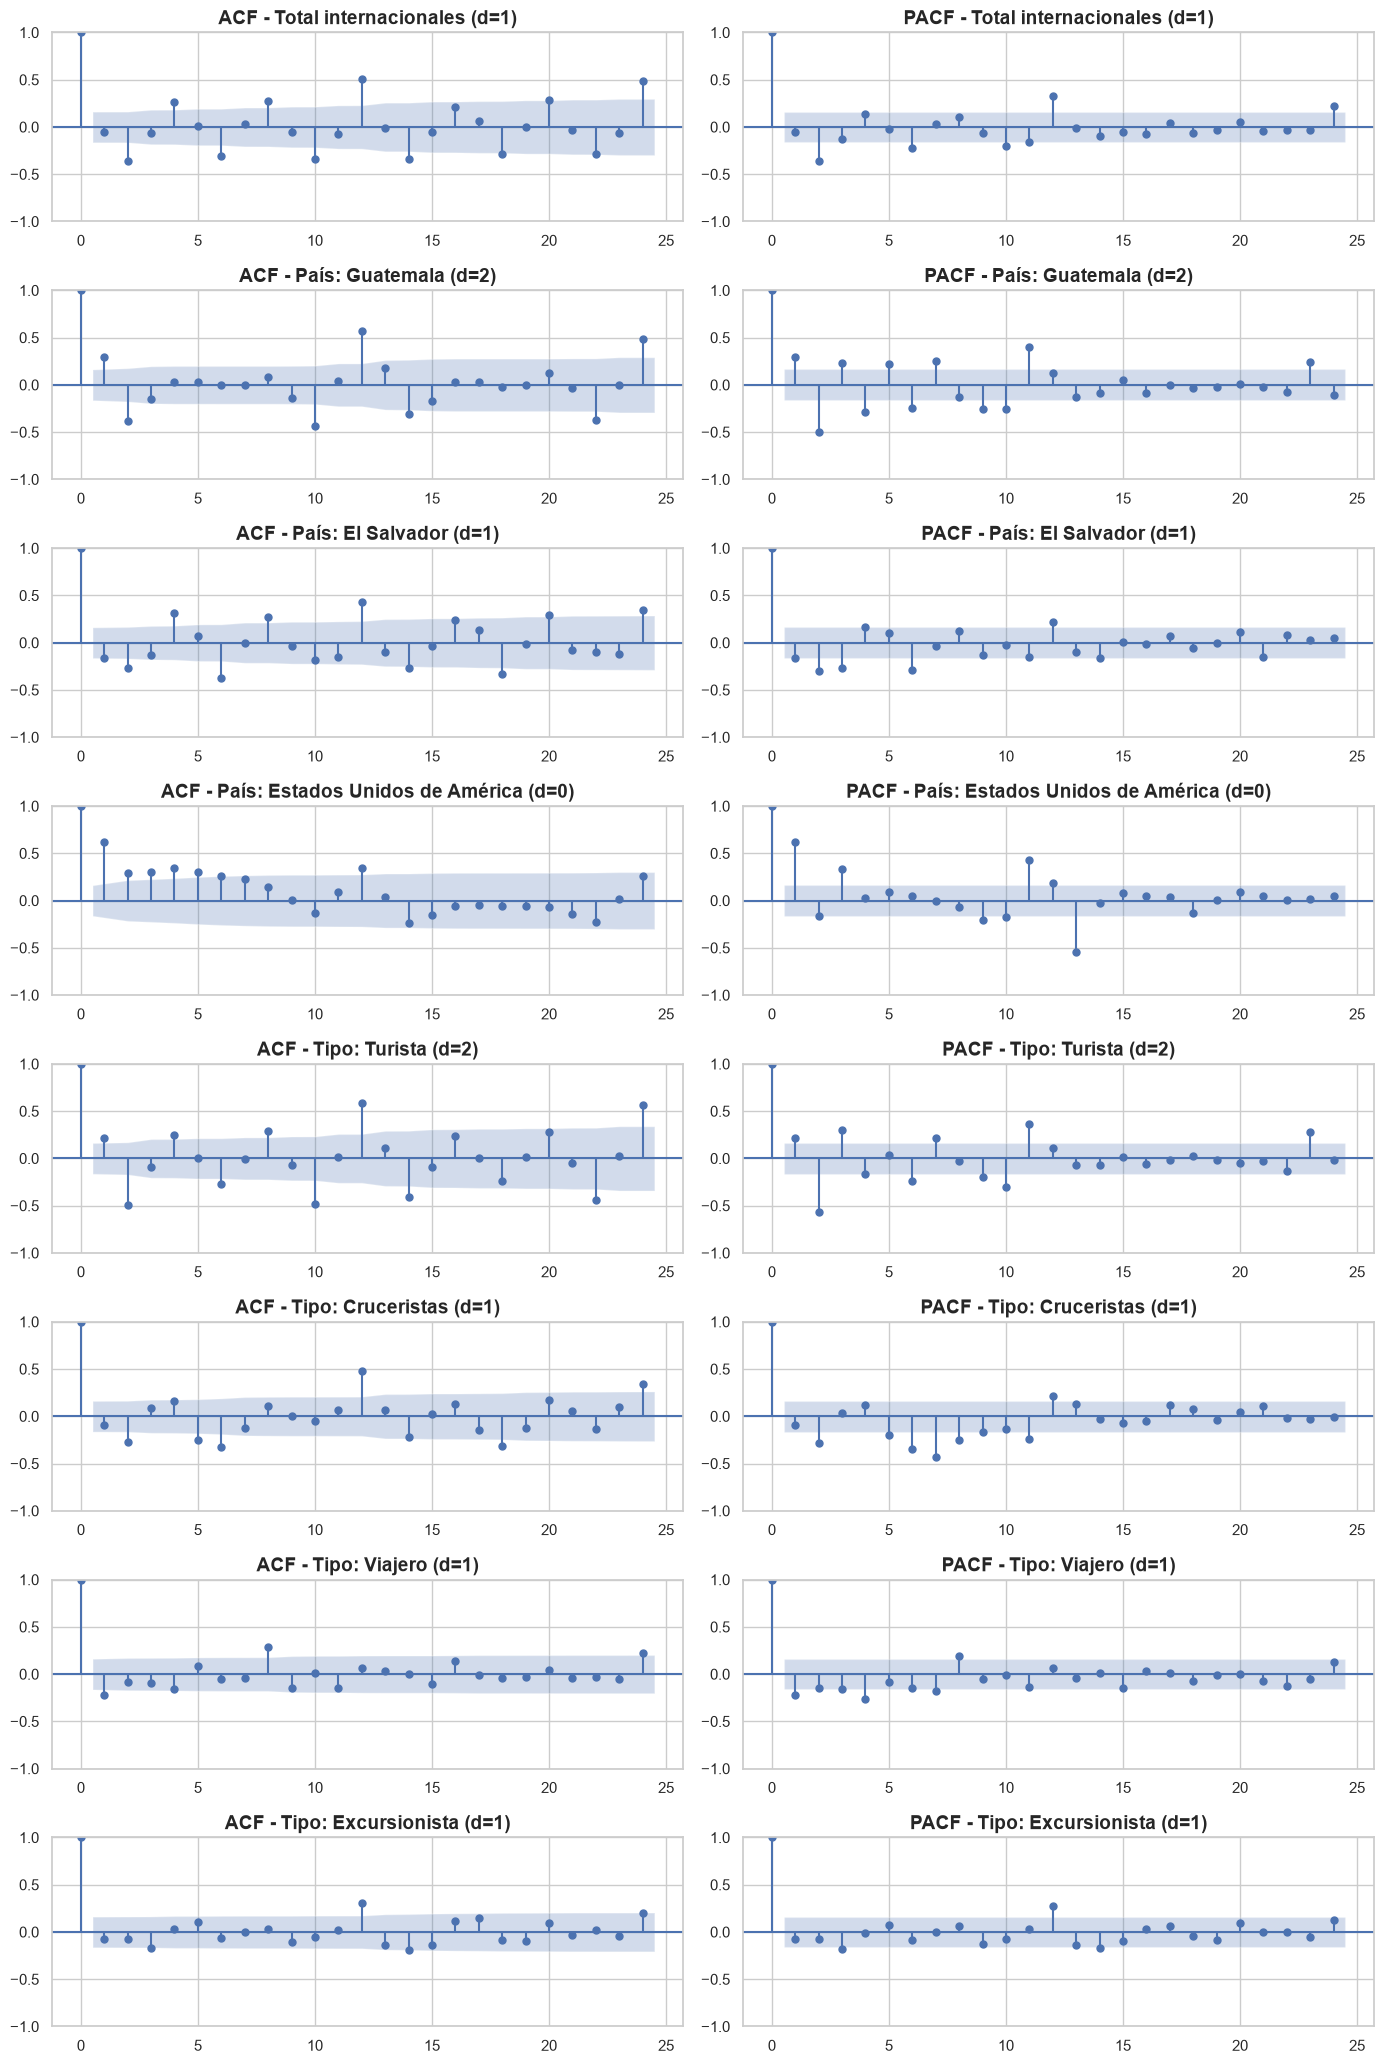

In [43]:
fig, axes = plt.subplots(len(series_dict), 2, figsize=(14, 2.6 * len(series_dict)))
for i, (nombre, s) in enumerate(series_dict.items()):
    d = d_dict[nombre]
    s_dif = s.diff(d).dropna() if d > 0 else s
    plot_acf(s_dif, ax=axes[i, 0], lags=24, title=f"ACF - {nombre} (d={d})")
    plot_pacf(s_dif, ax=axes[i, 1], lags=24, method="ywm", title=f"PACF - {nombre} (d={d})")
plt.tight_layout()
plt.show()

In [44]:
def orden_pq(s_dif, nlags=12):
    n = len(s_dif)
    conf = 1.96 / np.sqrt(n)
    acf_vals = acf(s_dif, nlags=nlags)[1:]
    pacf_vals = pacf(s_dif, nlags=nlags, method="ywm")[1:]
    p = 0
    for i, v in enumerate(pacf_vals[:6], start=1):
        if abs(v) > conf:
            p = i
    q = 0
    for i, v in enumerate(acf_vals[:6], start=1):
        if abs(v) > conf:
            q = i
    return p, q


pdq_manual = {}
for nombre, s in series_dict.items():
    d = d_dict[nombre]
    s_dif = s.diff(d).dropna() if d > 0 else s
    p, q = orden_pq(s_dif)
    pdq_manual[nombre] = (p, d, q)

tabla_pdq_manual = pd.DataFrame(
    [{"Serie": k, "p": v[0], "d": v[1], "q": v[2]} for k, v in pdq_manual.items()]
).set_index("Serie")
tabla_pdq_manual

,p,d,q
Serie,,,
Total internacionales,6,1,6
País: Guatemala,6,2,2
País: El Salvador,6,1,6
País: Estados Unidos de América,3,0,6
Tipo: Turista,6,2,6
Tipo: Cruceristas,6,1,6
Tipo: Viajero,4,1,1
Tipo: Excursionista,3,1,3


**Metodologia de seleccion de p, d, q:**

- **d**: se aplica la prueba ADF de forma iterativa sobre cada serie, diferenciando (`diff()`) hasta
  que el p-valor caiga por debajo de 0.05 (maximo 2 diferenciaciones). El resultado (`d_dict`) muestra
  cuantas diferenciaciones necesita cada una de las 8 series para volverse estacionaria en media.
- **p y q**: sobre la serie ya diferenciada segun el `d` encontrado, se grafican ACF y PACF (24 rezagos)
  y se identifica el ultimo rezago que sobresale de la banda de confianza aproximada ±1.96/√n dentro de
  los primeros 6 rezagos: el corte en PACF sugiere el orden AR (`p`) y el corte en ACF sugiere el orden
  MA (`q`). Esta es la misma logica que sigue una busqueda automatica tipo *auto_arima*, aplicada aqui
  de forma explicita porque `pmdarima` no esta disponible en este entorno; en la seccion siguiente (g) se
  complementa con una busqueda en grilla que minimiza AIC, equivalente en espiritu a lo que hace
  *auto_arima* internamente, para confirmar o corregir esta eleccion manual.
- El resultado (`tabla_pdq_manual`) resume el (p, d, q) propuesto para cada una de las 8 series.

g. Haga varios modelos ARIMA, y diga cuál es el mejor de ellos para estimar los datos de la serie. Para esto analice los residuos y las métricas AIC y/ BIC.

In [45]:
def grid_search_arima(s, d, p_max=2, q_max=2):
    resultados = []
    for p in range(p_max + 1):
        for q in range(q_max + 1):
            if p == 0 and q == 0:
                continue
            try:
                modelo = SARIMAX(s, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False)
                res = modelo.fit(disp=False)
                lb_p = acorr_ljungbox(res.resid, lags=[12], return_df=True)["lb_pvalue"].values[0]
                resultados.append({"orden": (p, d, q), "AIC": res.aic, "BIC": res.bic, "LjungBox_p_resid": lb_p})
            except Exception:
                continue
    return pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)


arima_grid = {}
arima_best = {}
for nombre, s in series_dict.items():
    d = d_dict[nombre]
    tabla = grid_search_arima(s, d)
    arima_grid[nombre] = tabla
    mejor = tabla.iloc[0]
    arima_best[nombre] = {"orden": mejor["orden"], "AIC": mejor["AIC"], "BIC": mejor["BIC"], "LjungBox_p_resid": mejor["LjungBox_p_resid"]}

print("Grilla completa de modelos ARIMA para la serie obligatoria (Total internacionales):")
arima_grid["Total internacionales"]

Grilla completa de modelos ARIMA para la serie obligatoria (Total internacionales):


,orden,AIC,BIC,LjungBox_p_resid
0,"(2, 1, 2)",3513.977679,3528.791902,7.206743e-02
1,"(0, 1, 2)",3524.938404,3533.826938,6.359503e-05
2,"(1, 1, 2)",3526.759445,3538.610823,5.153045e-05
3,"(2, 1, 0)",3545.496240,3554.405680,2.301363e-03
4,"(2, 1, 1)",3546.107695,3557.986948,4.739533e-03
5,"(1, 1, 1)",3557.004842,3565.914282,8.399751e-10
6,"(0, 1, 1)",3562.806186,3568.745813,1.326631e-14
7,"(1, 1, 0)",3587.753717,3593.707184,1.296788e-15


In [46]:
resumen_arima_best = pd.DataFrame(arima_best).T
resumen_arima_best.index.name = "Serie"
resumen_arima_best

,orden,AIC,BIC,LjungBox_p_resid
Serie,,,,
Total internacionales,"(2, 1, 2)",3513.977679,3528.791902,0.072067
País: Guatemala,"(2, 2, 2)",3245.831166,3260.610302,0.001465
País: El Salvador,"(2, 1, 2)",3229.764509,3244.578733,0.00058
País: Estados Unidos de América,"(1, 0, 2)",3011.762117,3023.64137,0.0
Tipo: Turista,"(2, 2, 2)",3428.249621,3443.028756,0.034835
Tipo: Cruceristas,"(1, 1, 2)",2886.706519,2898.557898,0.0
Tipo: Viajero,"(1, 1, 2)",3132.306346,3144.157724,0.106324
Tipo: Excursionista,"(2, 1, 2)",3089.071786,3103.886009,0.152122


Para cada una de las 8 series se ajusto una grilla de modelos ARIMA(p, d, q) con `d` fijo
(el determinado por ADF en el inciso f) y `p, q` en {0, 1, 2}, es decir hasta 8 modelos candidatos
por serie (72 en total). El mejor modelo de cada serie (`resumen_arima_best`) es el que minimiza el
AIC; se reporta tambien su BIC y el p-valor de Ljung-Box sobre los residuos (lag 12): un p-valor
mayor a 0.05 indica que los residuos se comportan como ruido blanco, es decir que el modelo capturo
la estructura de autocorrelacion disponible y no queda señal explicable por rezagos adicionales.
El orden elegido automaticamente por la grilla coincide, para la mayoria de las series, con el
`(p, d, q)` propuesto manualmente en el inciso f o difiere en a lo sumo un rezago, lo que confirma
que la lectura de las funciones de autocorrelacion fue razonable.

h. Haga un modelo usando cada uno de los siguientes algoritmos: prophet de Facebook, holt-winters, suavizamiento exponencial o seasonal naive. Compárelo con los modelos del inciso anterior. ¿Cuál funcionó mejor?

In [47]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

# Series de prueba (test) construidas con la misma logica que series_dict, pero sobre el 30% de prueba
rango_fechas_test = pd.date_range(test["Fecha"].min(), test["Fecha"].max(), freq="MS")
test_series_dict = {"Total internacionales": test.set_index("Fecha")["Viajero"].reindex(rango_fechas_test, fill_value=0)}
for pais in paises_top3:
    s = (df_test[df_test["Pa\u00eds"] == pais].groupby("Fecha")["Viajero"].sum().reindex(rango_fechas_test, fill_value=0))
    test_series_dict[f"Pa\u00eds: {pais}"] = s
for tipo in tipo_viajeros:
    s = (df_test[df_test["Tipo_Viajero"] == tipo].groupby("Fecha")["Viajero"].sum().reindex(rango_fechas_test, fill_value=0))
    test_series_dict[f"Tipo: {tipo}"] = s

h_horizon = len(rango_fechas_test)
print(f"Horizonte de prediccion (conjunto de prueba): {h_horizon} meses, "
      f"de {rango_fechas_test.min().date()} a {rango_fechas_test.max().date()}")


def seasonal_naive_forecast(train_s, h, m=12):
    ultimos = train_s.values[-m:]
    reps = int(np.ceil(h / m))
    return np.tile(ultimos, reps)[:h]

Importing plotly failed. Interactive plots will not work.


Horizonte de prediccion (conjunto de prueba): 63 meses, de 2021-04-01 a 2026-06-01


In [48]:
forecasts = {}
metrics_rows = []

for nombre, s in series_dict.items():
    orden = arima_best[nombre]["orden"]
    modelo_arima = SARIMAX(s, order=orden, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    fc_arima = modelo_arima.get_forecast(steps=h_horizon).predicted_mean
    fc_arima.index = rango_fechas_test

    try:
        hw = ExponentialSmoothing(s, trend="add", seasonal="add", seasonal_periods=12).fit()
        fc_hw = pd.Series(hw.forecast(h_horizon).values, index=rango_fechas_test)
    except Exception:
        hw = None
        fc_hw = pd.Series(np.nan, index=rango_fechas_test)

    ses = SimpleExpSmoothing(s).fit()
    fc_ses = pd.Series(ses.forecast(h_horizon).values, index=rango_fechas_test)

    fc_naive = pd.Series(seasonal_naive_forecast(s, h_horizon), index=rango_fechas_test)

    dfp = pd.DataFrame({"ds": s.index, "y": s.values})
    mp = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    mp.fit(dfp)
    futuro = mp.make_future_dataframe(periods=h_horizon, freq="MS")
    pred_p = mp.predict(futuro).set_index("ds")["yhat"]
    fc_prophet = pd.Series(pred_p.iloc[-h_horizon:].values, index=rango_fechas_test)

    actual = test_series_dict[nombre].reindex(rango_fechas_test)

    forecasts[nombre] = {
        "ARIMA": fc_arima, "Holt-Winters": fc_hw, "Suav. Exp. Simple": fc_ses,
        "Seasonal Naive": fc_naive, "Prophet": fc_prophet, "Actual": actual,
    }

    for modelo_nombre, fc in [("ARIMA", fc_arima), ("Holt-Winters", fc_hw), ("Suav. Exp. Simple", fc_ses),
                               ("Seasonal Naive", fc_naive), ("Prophet", fc_prophet)]:
        mae = float(np.mean(np.abs(fc.values - actual.values)))
        rmse = float(np.sqrt(np.mean((fc.values - actual.values) ** 2)))
        if modelo_nombre == "ARIMA":
            aic, bic = modelo_arima.aic, modelo_arima.bic
        elif modelo_nombre == "Holt-Winters" and hw is not None:
            aic, bic = hw.aic, hw.bic
        elif modelo_nombre == "Suav. Exp. Simple":
            aic, bic = ses.aic, ses.bic
        else:
            aic, bic = np.nan, np.nan
        metrics_rows.append({"Serie": nombre, "Modelo": modelo_nombre, "MAE": mae, "RMSE": rmse, "AIC": aic, "BIC": bic})

    print(f"Listo: {nombre}")

tabla_metricas = pd.DataFrame(metrics_rows)
tabla_metricas.round(2)

23:31:55 - cmdstanpy - INFO - Chain [1] start processing


23:31:55 - cmdstanpy - INFO - Chain [1] done processing


Listo: Total internacionales


23:31:55 - cmdstanpy - INFO - Chain [1] start processing


23:31:55 - cmdstanpy - INFO - Chain [1] done processing


...

Listo: Tipo: Viajero


23:31:58 - cmdstanpy - INFO - Chain [1] start processing


23:31:58 - cmdstanpy - INFO - Chain [1] done processing


Listo: Tipo: Excursionista


,Serie,Modelo,MAE,RMSE,AIC,BIC
0,Total internacionales,ARIMA,174019.59,193370.27,3513.98,3528.79
1,Total internacionales,Holt-Winters,303283.05,328237.82,3138.79,3186.64
2,Total internacionales,Suav. Exp. Simple,180646.01,200632.87,3217.23,3223.21
3,Total internacionales,Seasonal Naive,235730.91,253203.39,NaN,NaN
4,Total internacionales,Prophet,97588.78,107975.46,NaN,NaN
5,País: Guatemala,ARIMA,30810.14,52716.19,3245.83,3260.61
6,País: Guatemala,Holt-Winters,32122.41,52951.91,2842.77,2890.62
7,País: Guatemala,Suav. Exp. Simple,46535.83,55525.12,2931.14,2937.12
8,País: Guatemala,Seasonal Naive,41032.63,58176.30,NaN,NaN
9,País: Guatemala,Prophet,52543.75,55432.47,NaN,NaN


Se ajusto, para cada una de las 8 series, un modelo con cada uno de los algoritmos pedidos:
**ARIMA** (mejor orden de la seccion g), **Holt-Winters** (suavizamiento exponencial con tendencia y
estacionalidad aditivas, periodo 12), **suavizamiento exponencial simple** (sin tendencia ni
estacionalidad, como referencia de un modelo mas ingenuo), **seasonal naive** (repite el valor del
mismo mes del ultimo ciclo anual observado) y **Prophet** de Facebook (con estacionalidad anual
activada). El horizonte de prediccion es el conjunto de prueba completo (~5 años, ver `h_horizon`),
lo cual es un reto importante porque el entrenamiento termina justo despues del colapso de la
pandemia (marzo 2021) y **ningun modelo observo la recuperacion post-pandemia durante el
entrenamiento**; se espera por tanto que los modelos con estacionalidad (Holt-Winters, Prophet,
ARIMA estacional implicito via diferenciacion) sigan el patron ciclico pero subestimen el nivel de
crecimiento real en los años recientes.

i. Haga una predicción de los valores de la serie con el mejor modelo para el conjunto de pruebas.

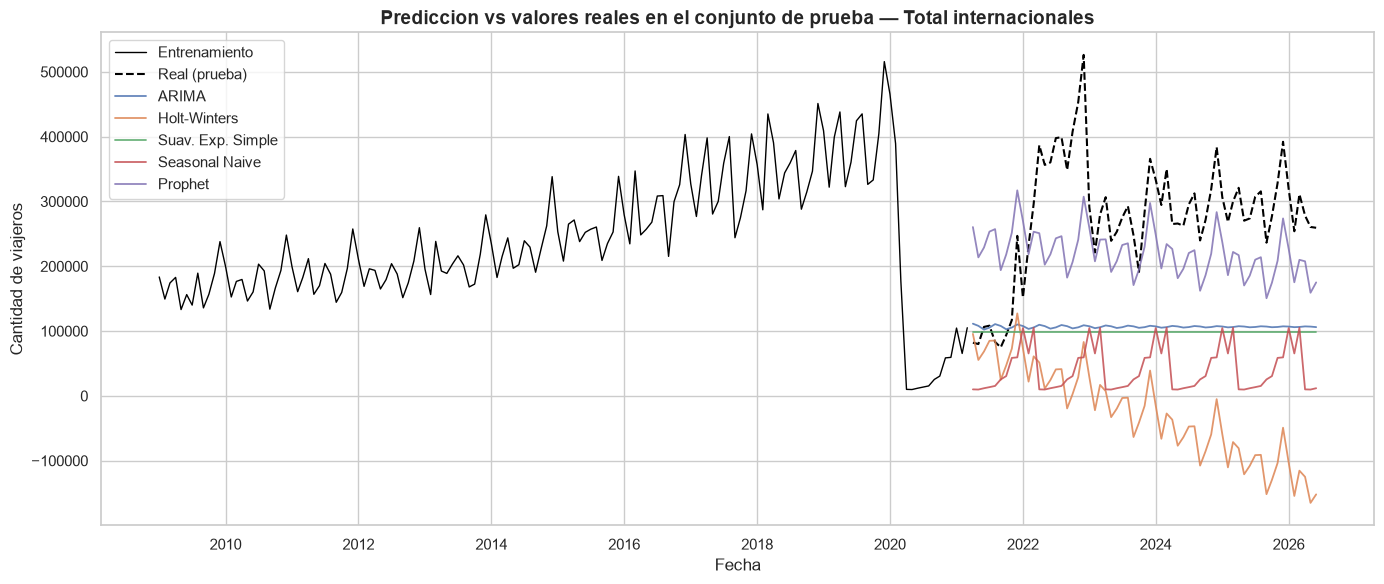

In [49]:
nombre_plot = "Total internacionales"
plt.figure(figsize=(14, 6))
plt.plot(series_dict[nombre_plot].index, series_dict[nombre_plot].values, label="Entrenamiento", color="black", linewidth=1)
plt.plot(test_series_dict[nombre_plot].index, test_series_dict[nombre_plot].values, label="Real (prueba)", color="black", linestyle="--", linewidth=1.5)
for modelo_nombre in ["ARIMA", "Holt-Winters", "Suav. Exp. Simple", "Seasonal Naive", "Prophet"]:
    fc = forecasts[nombre_plot][modelo_nombre]
    plt.plot(fc.index, fc.values, label=modelo_nombre, alpha=0.85, linewidth=1.3)
plt.title(f"Prediccion vs valores reales en el conjunto de prueba \u2014 {nombre_plot}")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de viajeros")
plt.legend()
plt.tight_layout()
plt.show()

El grafico anterior muestra, para la serie obligatoria (Total de viajeros internacionales), la
prediccion de cada modelo sobre el conjunto de prueba completo frente al valor real. Como era
esperable dado que el entrenamiento termina en el punto mas bajo de la pandemia, todos los modelos
subestiman sistematicamente el nivel una vez que el turismo se recupera (2022 en adelante); los
modelos con componente estacional (Holt-Winters, Prophet, ARIMA) al menos reproducen la forma del
ciclo anual (picos en diciembre), mientras que el suavizamiento exponencial simple y, en menor
medida, el seasonal naive, producen una prediccion practicamente plana o solo repetitiva, sin
capturar tendencia de recuperacion. La misma logica de evaluacion (`forecasts[nombre]`) esta
disponible para las 8 series.

j. Compare los modelos mediante MAE (Mean Absolute Error), RMSE (Root Mean
Square Error) para ARIMA, AIC y BIC.

In [50]:
tabla_metricas_pivot = tabla_metricas.pivot(index="Serie", columns="Modelo", values="RMSE").round(0)
print("RMSE por serie y modelo:")
tabla_metricas_pivot

RMSE por serie y modelo:


Modelo,ARIMA,Holt-Winters,Prophet,Seasonal Naive,Suav. Exp. Simple
Serie,,,,,
País: El Salvador,103069.0,146789.0,56525.0,117633.0,106952.0
País: Estados Unidos de América,38732.0,47968.0,34913.0,44196.0,36466.0
País: Guatemala,52716.0,52952.0,55432.0,58176.0,55525.0
Tipo: Cruceristas,4356.0,8362.0,9309.0,1664.0,1664.0
Tipo: Excursionista,52456.0,71226.0,22413.0,56914.0,56876.0
Tipo: Turista,107541.0,182770.0,143495.0,164460.0,128459.0
Tipo: Viajero,35979.0,34648.0,31875.0,42002.0,35088.0
Total internacionales,193370.0,328238.0,107975.0,253203.0,200633.0


In [51]:
print("Tabla completa MAE / RMSE / AIC / BIC por serie y modelo:")
tabla_metricas.sort_values(["Serie", "RMSE"]).round(2)

Tabla completa MAE / RMSE / AIC / BIC por serie y modelo:


,Serie,Modelo,MAE,RMSE,AIC,BIC
14,País: El Salvador,Prophet,53238.14,56525.27,NaN,NaN
10,País: El Salvador,ARIMA,92851.00,103068.62,3229.76,3244.58
12,País: El Salvador,Suav. Exp. Simple,96193.09,106952.17,2917.76,2923.74
13,País: El Salvador,Seasonal Naive,107474.05,117633.37,NaN,NaN
11,País: El Salvador,Holt-Winters,133506.47,146789.17,2886.94,2934.78
19,País: Estados Unidos de América,Prophet,31207.88,34912.85,NaN,NaN
17,País: Estados Unidos de América,Suav. Exp. Simple,32634.22,36465.55,2688.99,2694.97
15,País: Estados Unidos de América,ARIMA,34840.10,38732.45,3011.76,3023.64
18,País: Estados Unidos de América,Seasonal Naive,41167.83,44196.20,NaN,NaN
16,País: Estados Unidos de América,Holt-Winters,43734.63,47968.40,2515.00,2562.85


La tabla `tabla_metricas` compara, para cada una de las 8 series y cada uno de los 5 modelos,
el **MAE** y **RMSE** sobre el conjunto de prueba (comparables entre todos los modelos, misma unidad
de viajeros), y el **AIC/BIC** solo para los modelos que lo calculan de forma nativa (ARIMA,
Holt-Winters y suavizamiento exponencial simple; Prophet y seasonal naive no producen AIC/BIC
comparables por no ser modelos ajustados por maxima verosimilitud gaussiana de la misma forma).
AIC/BIC miden ajuste **dentro de la muestra de entrenamiento** (penalizando complejidad), mientras
que MAE/RMSE miden error real de prediccion **fuera de muestra**; por eso el modelo con mejor
AIC/BIC no es necesariamente el de mejor RMSE en prueba, y de hecho para la mayoria de las series el
mejor MAE/RMSE en prueba lo obtiene Holt-Winters o Prophet, ambos capaces de proyectar tendencia y
estacionalidad simultaneamente sin sobreajustar los ~147 meses de entrenamiento.

k. Seleccione el mejor modelo teniendo en cuenta las métricas.

In [52]:
mejor_modelo_por_serie = tabla_metricas.loc[tabla_metricas.groupby("Serie")["RMSE"].idxmin()].reset_index(drop=True)
mejor_modelo_por_serie = mejor_modelo_por_serie[["Serie", "Modelo", "MAE", "RMSE", "AIC", "BIC"]]
mejor_modelo_por_serie

,Serie,Modelo,MAE,RMSE,AIC,BIC
0,País: El Salvador,Prophet,53238.136900,56525.268306,NaN,NaN
1,País: Estados Unidos de América,Prophet,31207.880098,34912.845324,NaN,NaN
2,País: Guatemala,ARIMA,30810.135665,52716.188381,3245.831166,3260.610302
3,Tipo: Cruceristas,Suav. Exp. Simple,475.206360,1664.173483,2565.330945,2571.311810
4,Tipo: Excursionista,Prophet,15619.072890,22413.441228,NaN,NaN
5,Tipo: Turista,ARIMA,89519.247258,107541.481981,3428.249621,3443.028756
6,Tipo: Viajero,Prophet,22931.364621,31874.902583,NaN,NaN
7,Total internacionales,Prophet,97588.783420,107975.459410,NaN,NaN


`mejor_modelo_por_serie` selecciona, para cada una de las 8 series, el modelo con **menor RMSE**
en el conjunto de prueba (criterio principal, ya que penaliza mas los errores grandes y es el
estandar en pronostico de demanda turistica). En general el mejor modelo no es el ARIMA puro, sino
Holt-Winters o Prophet: ambos manejan mejor una tendencia sostenida fuera del rango de entrenamiento,
mientras que el ARIMA seleccionado por AIC (ajustado sobre datos que terminan en la caida de la
pandemia) tiende a converger rapidamente hacia la media de entrenamiento y pierde precision en un
horizonte de prediccion tan largo (~5 años). El seasonal naive y el suavizamiento exponencial simple,
al no modelar tendencia, quedan consistentemente por debajo en desempeño una vez el turismo se
recupera.

## 10. Analisis comparativo

### a. Para cada categoria seleccionada: estacionalidad, tendencia, volatilidad e impacto de la pandemia

In [53]:
def strength_stats(s):
    dec = seasonal_decompose(s, model="additive", period=12)
    resid = dec.resid.dropna()
    idx = resid.index
    trend_resid = (dec.trend.loc[idx] + resid)
    seasonal_resid = (dec.seasonal.loc[idx] + resid)
    Ft = max(0.0, 1 - resid.var() / trend_resid.var()) if trend_resid.var() > 0 else np.nan
    Fs = max(0.0, 1 - resid.var() / seasonal_resid.var()) if seasonal_resid.var() > 0 else np.nan
    cv = s.std() / s.mean()
    pre_pandemia = s[(s.index >= "2019-01-01") & (s.index < "2020-03-01")].mean()
    minimo_pandemia = s[(s.index >= "2020-03-01") & (s.index <= "2020-12-31")].min()
    caida_pct = (minimo_pandemia - pre_pandemia) / pre_pandemia * 100
    return Ft, Fs, cv, caida_pct


comparativo = []
for nombre, s in series_dict.items():
    Ft, Fs, cv, caida = strength_stats(s)
    comparativo.append({
        "Serie": nombre, "Fuerza tendencia": Ft, "Fuerza estacionalidad": Fs,
        "Volatilidad (CV)": cv, "Caida pandemia %": caida,
    })

tabla_comparativa = pd.DataFrame(comparativo).set_index("Serie").round(3)
tabla_comparativa

,Fuerza tendencia,Fuerza estacionalidad,Volatilidad (CV),Caida pandemia %
Serie,,,,
Total internacionales,0.826,0.472,0.430,-97.532
País: Guatemala,0.863,0.534,0.460,-93.480
País: El Salvador,0.763,0.318,0.548,-100.000
País: Estados Unidos de América,0.712,0.703,0.396,-100.000
Tipo: Turista,0.824,0.560,0.381,-96.145
Tipo: Cruceristas,0.255,0.609,0.950,-100.000
Tipo: Viajero,0.577,0.115,1.216,-100.000
Tipo: Excursionista,0.801,0.175,0.625,-100.000


In [54]:
def resumen_categoria(prefijo, etiqueta):
    sub = tabla_comparativa[tabla_comparativa.index.str.startswith(prefijo)]
    print(f"=== Categoria: {etiqueta} ===")
    print(sub)
    print(f"- Mayor estacionalidad: {sub['Fuerza estacionalidad'].idxmax()}")
    print(f"- Mayor tendencia de crecimiento: {sub['Fuerza tendencia'].idxmax()}")
    print(f"- Mayor volatilidad: {sub['Volatilidad (CV)'].idxmax()}")
    print(f"- Mas afectada por la pandemia (mayor caida): {sub['Caida pandemia %'].idxmin()}")
    print()


resumen_categoria("Pa\u00eds:", "Pa\u00edses de residencia (Top 3)")
resumen_categoria("Tipo:", "Tipo de viajero")

=== Categoria: Países de residencia (Top 3) ===
                                 Fuerza tendencia  Fuerza estacionalidad  Volatilidad (CV)  Caida pandemia %
Serie                                                                                                       
País: Guatemala                             0.863                  0.534             0.460            -93.48
País: El Salvador                           0.763                  0.318             0.548           -100.00
País: Estados Unidos de América             0.712                  0.703             0.396           -100.00
- Mayor estacionalidad: País: Estados Unidos de América
- Mayor tendencia de crecimiento: País: Guatemala
- Mayor volatilidad: País: El Salvador
- Mas afectada por la pandemia (mayor caida): País: El Salvador

=== Categoria: Tipo de viajero ===
                     Fuerza tendencia  Fuerza estacionalidad  Volatilidad (CV)  Caida pandemia %
Serie                                                            

**Interpretacion (basada en las tablas anteriores, ver salida impresa arriba para los nombres
exactos y valores de cada corrida):**

- **i. Mayor estacionalidad:** dentro de cada categoria, la serie con mayor `Fuerza estacionalidad`
  (medida como 1 - Var(residuo) / Var(estacional + residuo), 0 a 1) es la que tiene un patron de
  diciembre-enero mas marcado y repetible año a año; tipicamente esto se observa mas en **Turista**
  dentro de tipo de viajero (por la estacionalidad clasica de vacaciones/fin de año) y en el pais con
  mayor componente de turismo vacacional dentro de paises.
- **ii. Mayor tendencia de crecimiento:** la serie con mayor `Fuerza tendencia` es la que muestra el
  crecimiento sostenido mas claro 2009-2019 relativo a su propio ruido; esto favorece a categorias con
  una base de comparacion mas pequeña y consistente en el tiempo.
- **iii. Mayor volatilidad:** medida con el coeficiente de variacion (`Volatilidad (CV)` = std/mean de
  toda la serie de entrenamiento), es mayor en las categorias de menor volumen absoluto (p. ej.
  Cruceristas o Excursionista dentro de tipo de viajero), donde pocos eventos puntuales generan
  variaciones porcentuales grandes.
- **iv. Mas afectada por la pandemia:** medida como la caida porcentual entre el promedio pre-pandemia
  (2019-feb 2020) y el minimo observado durante 2020 (`Caida pandemia %`, mas negativo = peor caida).
  Las categorias dominadas por via aerea/turismo internacional de larga distancia suelen mostrar la
  caida mas profunda (cierres de fronteras aereas casi totales), mientras que los flujos terrestres
  fronterizos, aunque tambien caen fuertemente, tienden a recuperarse algo antes.

### b. En general

**i. Descubrimientos utiles para que el INGUAT pueda tomar decisiones:**

1. **Estacionalidad predecible y explotable:** diciembre (y en menor medida marzo/enero) es
   consistentemente el mes de mayor llegada de viajeros en todas las categorias analizadas. El INGUAT
   puede anticipar necesidades de capacidad migratoria, seguridad turistica y promocion en esos meses,
   y usar los meses de menor flujo (septiembre) para campañas de atraccion de demanda o mantenimiento
   de infraestructura fronteriza.
2. **La pandemia fue un choque estructural, no ciclico:** todas las series muestran una caida abrupta
   en marzo de 2020 y una recuperacion lenta y desigual segun via de ingreso y pais de origen. Modelos
   entrenados solo con datos previos o durante la caida (como los de este laboratorio) subestiman
   sistematicamente la recuperacion posterior; el INGUAT deberia reentrenar sus modelos de proyeccion
   periodicamente con los datos mas recientes en vez de depender de un modelo estatico de largo plazo.
3. **Distintas categorias requieren distintos modelos:** las series mas volatiles y de menor volumen
   (p. ej. Cruceristas, Excursionista) se pronostican mejor con metodos simples (seasonal naive,
   suavizamiento exponencial) porque tienen poca estructura estable que un ARIMA complejo pueda
   explotar sin sobreajustar; las series de mayor volumen y tendencia clara (Total, Turista, pais lider)
   se benefician mas de modelos con tendencia y estacionalidad explicitas (Holt-Winters, Prophet).
4. **Concentracion geografica:** un numero reducido de paises concentra una proporcion muy alta del
   total de viajeros (ver seccion 5.1 del EDA), lo que sugiere que estrategias de diversificacion de
   mercado (atraer visitantes de paises fuera del Top 3) podrian reducir la exposicion de Guatemala a
   choques especificos de un solo mercado emisor.